# Ship Detection in Satellite Imagery

**Course:** MTH/CSE 4224 - Intro to Machine Learning  
**Project:** Binary ship detection from 80x80 RGB satellite image chips  
**Dataset:** Kaggle ShipsNet-style `shipsnet.json` with 4,000 labeled images

This notebook is designed to run from top to bottom in Google Colab. It performs data loading, validation, exploratory analysis, feature engineering, benchmark modeling, tuned modeling, unsupervised analysis, CNN training, and artifact export for the final report and presentation.

## Project Question

Can traditional machine-learning models trained on hand-crafted image features compete with a CNN trained directly on image pixels for ship detection in satellite imagery?

## Rubric Checklist

- Data preparation: load, validate, reshape, normalize, split, and inspect the dataset.
- Benchmarking: train basic untuned models before tuning.
- Training and tuning: compare multiple supervised models with cross-validation and a held-out test set.
- Communication: save figures/tables for the report and presentation.
- Conclusions: summarize best model, tradeoffs, and limitations.

## 1. Colab Setup

Run the next cells first. They install any missing libraries, configure reproducibility, and create an artifact folder. Figures and tables are both displayed inline and saved under `outputs/` so they can be reused in the final report and presentation.

**Recommended Colab runtime:** GPU for the CNN section (`Runtime > Change runtime type > T4 GPU`). Traditional ML sections can run on CPU.

In [1]:
# Colab/runtime setup
import importlib.util
import os
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Install only packages that are not already available. Colab usually has most of these.
def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for import_name, pip_name in [
    ("numpy", None),
    ("pandas", None),
    ("sklearn", "scikit-learn"),
    ("skimage", "scikit-image"),
    ("cv2", "opencv-python-headless"),
    ("seaborn", None),
    ("xgboost", None),
]:
    ensure_package(import_name, pip_name)

import cv2
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["savefig.dpi"] = 180

print(f"Running in Colab: {IN_COLAB}")
print(f"Python: {sys.version.split()[0]}")

Running in Colab: True
Python: 3.12.13


In [2]:
# Optional Google Drive mount and artifact configuration
if IN_COLAB:
    from google.colab import drive, files

    MOUNT_DRIVE = True  # Set False if you prefer manual upload every runtime.
    if MOUNT_DRIVE:
        drive.mount("/content/drive")
else:
    files = None

PROJECT_NAME = "Project 2"

candidate_project_dirs = []
if IN_COLAB:
    candidate_project_dirs.extend([
        Path("/content/drive/MyDrive/Project 2"),
        Path("/content/drive/MyDrive/Machine Learning/Project 2"),
        Path("/content/drive/MyDrive/School/Spring_2026/Machine Learning/Project 2"),
        Path("/content"),
    ])

candidate_project_dirs.extend([
    Path.cwd(),
    Path.cwd() / "Project 2",
])

PROJECT_DIR = next((p for p in candidate_project_dirs if (p / "data" / "shipsnet.json").exists()), candidate_project_dirs[0])
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

def find_or_upload_shipsnet_json():
    """Find shipsnet.json from Drive/local paths, or prompt upload in Colab."""
    candidates = [
        DATA_DIR / "shipsnet.json",
        PROJECT_DIR / "shipsnet.json",
        Path.cwd() / "data" / "shipsnet.json",
        Path.cwd() / "shipsnet.json",
        Path("/content/shipsnet.json"),
    ]
    for path in candidates:
        if path.exists():
            return path

    if IN_COLAB:
        print("shipsnet.json was not found. Upload it now, or place it in Drive under Project 2/data/.")
        uploaded = files.upload()
        for name in uploaded:
            if name.lower().endswith(".json"):
                upload_path = Path("/content") / name
                return upload_path

    raise FileNotFoundError("Could not locate shipsnet.json. Put it in data/shipsnet.json or upload it in Colab.")

DATA_PATH = find_or_upload_shipsnet_json()
print(f"Using dataset: {DATA_PATH}")

def save_fig(name, fig=None, tight=True):
    """Save a matplotlib figure to OUTPUT_DIR and keep it visible inline."""
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()
    path = OUTPUT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

def save_table(df, name, index=False, display_inline=True):
    """Save a pandas table to OUTPUT_DIR and optionally display it inline."""
    path = OUTPUT_DIR / name
    df.to_csv(path, index=index)
    if display_inline:
        display(df)
    print(f"Saved table: {path}")
    return path

def save_markdown(text, name):
    path = OUTPUT_DIR / name
    path.write_text(text, encoding="utf-8")
    print(f"Saved markdown: {path}")
    return path

ARTIFACTS = []

def track_artifact(path, description, use):
    ARTIFACTS.append({"file": str(path), "description": description, "suggested_use": use})
    return path

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Project 2
DATA_DIR: /content/drive/MyDrive/Project 2/data
OUTPUT_DIR: /content/drive/MyDrive/Project 2/outputs
Using dataset: /content/drive/MyDrive/Project 2/data/shipsnet.json


## 2. Load, Validate, and Split the Dataset

The raw JSON contains flattened image vectors plus labels and metadata. ShipsNet stores each 80x80 RGB chip as 19,200 values. This notebook reshapes each vector into image tensors, preserves metadata, and creates a held-out test set for fair comparison across all models.

In [3]:
# Load and validate raw JSON
start_time = time.time()
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

required_keys = {"data", "labels", "locations", "scene_ids"}
missing = required_keys - set(raw)
if missing:
    raise ValueError(f"Missing expected keys: {missing}")

X_flat = np.asarray(raw["data"], dtype=np.uint8)
y = np.asarray(raw["labels"], dtype=np.int64)
locations = np.asarray(raw["locations"], dtype=np.float64)
scene_ids = np.asarray(raw["scene_ids"], dtype=str)

n_samples, n_pixels = X_flat.shape
expected_pixels = 80 * 80 * 3
assert n_pixels == expected_pixels, f"Expected {expected_pixels} pixels per image, got {n_pixels}"
assert len(y) == n_samples == len(locations) == len(scene_ids)

# ShipsNet-style JSON stores channels as flattened 80x80 channel blocks.
X_uint8 = X_flat.reshape(n_samples, 3, 80, 80).transpose(0, 2, 3, 1)
X = X_uint8.astype(np.float32) / 255.0

metadata = pd.DataFrame({
    "label": y,
    "class_name": np.where(y == 1, "ship", "no_ship"),
    "longitude": locations[:, 0],
    "latitude": locations[:, 1],
    "scene_id": scene_ids,
})

summary = pd.DataFrame({
    "item": ["samples", "pixels_per_image", "image_height", "image_width", "channels", "ship_count", "no_ship_count", "unique_scenes"],
    "value": [n_samples, n_pixels, 80, 80, 3, int((y == 1).sum()), int((y == 0).sum()), metadata["scene_id"].nunique()],
})

track_artifact(save_table(summary, "dataset_summary.csv"), "Dataset shape and class summary", "Report data preparation section")
print(f"Loaded and reshaped data in {time.time() - start_time:.1f} seconds")
print(f"X shape: {X.shape}, y shape: {y.shape}")

,item,value
0,samples,4000
1,pixels_per_image,19200
2,image_height,80
3,image_width,80
4,channels,3
5,ship_count,1000
6,no_ship_count,3000
7,unique_scenes,434


Saved table: /content/drive/MyDrive/Project 2/outputs/dataset_summary.csv
Loaded and reshaped data in 20.4 seconds
X shape: (4000, 80, 80, 3), y shape: (4000,)


In [4]:
# Train/test split with leakage diagnostics
TEST_SIZE = 0.20
SPLIT_STRATEGY = "stratified"  # Keep proposal-aligned split; use diagnostics below to discuss scene overlap.

all_indices = np.arange(n_samples)
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

# Also compute a scene-grouped alternative for leakage discussion.
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
group_train_idx, group_test_idx = next(gss.split(X_flat, y, groups=scene_ids))

def split_summary(name, tr_idx, te_idx):
    tr_scenes = set(scene_ids[tr_idx])
    te_scenes = set(scene_ids[te_idx])
    return {
        "split": name,
        "train_n": len(tr_idx),
        "test_n": len(te_idx),
        "train_ship_rate": y[tr_idx].mean(),
        "test_ship_rate": y[te_idx].mean(),
        "train_unique_scenes": len(tr_scenes),
        "test_unique_scenes": len(te_scenes),
        "scene_overlap": len(tr_scenes & te_scenes),
    }

split_df = pd.DataFrame([
    split_summary("stratified_random_used", train_idx, test_idx),
    split_summary("scene_grouped_diagnostic", group_train_idx, group_test_idx),
])
track_artifact(save_table(split_df, "split_diagnostics.csv"), "Train/test split diagnostics, including scene overlap", "Report data preparation and limitations")

X_train_img, X_test_img = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
meta_train, meta_test = metadata.iloc[train_idx].reset_index(drop=True), metadata.iloc[test_idx].reset_index(drop=True)

print("Using stratified train/test split for all supervised comparisons.")
print(f"Train: {X_train_img.shape}, Test: {X_test_img.shape}")

,split,train_n,test_n,train_ship_rate,test_ship_rate,train_unique_scenes,test_unique_scenes,scene_overlap
0,stratified_random_used,3200,800,0.25000,0.250000,425,322,313
1,scene_grouped_diagnostic,3196,804,0.24562,0.267413,347,87,0


Saved table: /content/drive/MyDrive/Project 2/outputs/split_diagnostics.csv
Using stratified train/test split for all supervised comparisons.
Train: (3200, 80, 80, 3), Test: (800, 80, 80, 3)


## 3. Exploratory Data Analysis

These cells create a compact set of report and presentation artifacts: class balance, representative image chips, pixel distributions, scene metadata summaries, and a simple pipeline diagram.

,class_name,count,percent
0,no_ship,3000,75.0
1,ship,1000,25.0


Saved table: /content/drive/MyDrive/Project 2/outputs/class_balance.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/class_balance.png


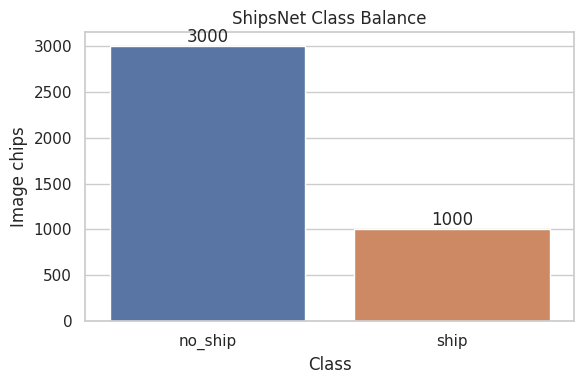

In [5]:
# Class balance
class_counts = metadata["class_name"].value_counts().rename_axis("class_name").reset_index(name="count")
class_counts["percent"] = 100 * class_counts["count"] / class_counts["count"].sum()
track_artifact(save_table(class_counts, "class_balance.csv"), "Class balance table", "Report data section")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=class_counts, x="class_name", y="count", ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("ShipsNet Class Balance")
ax.set_xlabel("Class")
ax.set_ylabel("Image chips")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
track_artifact(save_fig("class_balance.png", fig), "Class balance bar chart", "Report and presentation data overview")
plt.show()

Saved figure: /content/drive/MyDrive/Project 2/outputs/sample_images_by_class.png


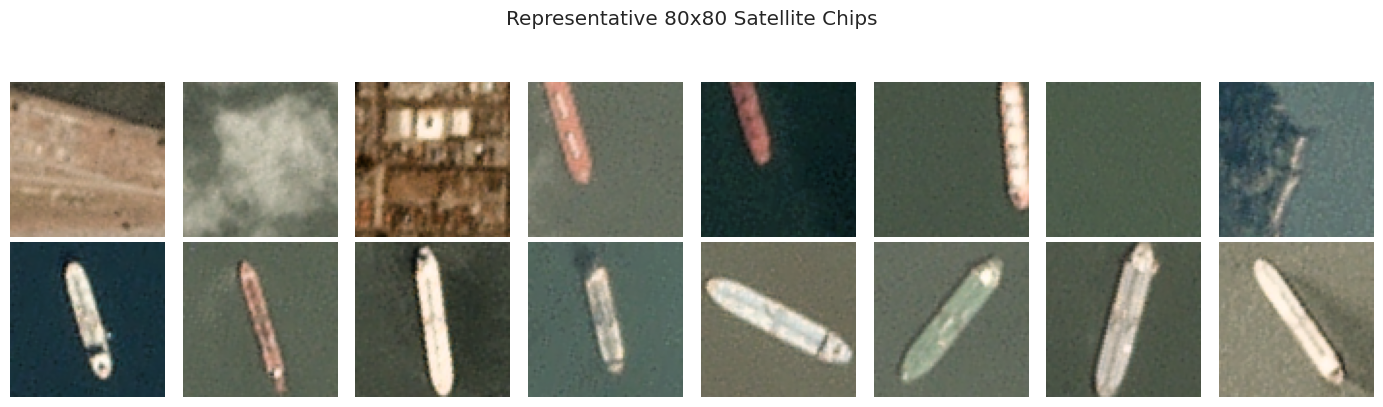

In [6]:
# Representative image chips by class
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([0, 1]):
    label_indices = np.where(y == label)[0]
    sample_indices = rng.choice(label_indices, size=8, replace=False)
    for col, idx in enumerate(sample_indices):
        ax = axes[row, col]
        ax.imshow(X_uint8[idx])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel("No ship" if label == 0 else "Ship", fontsize=12)
fig.suptitle("Representative 80x80 Satellite Chips", y=1.03)
track_artifact(save_fig("sample_images_by_class.png", fig), "Representative image chips by class", "Report data and presentation intro")
plt.show()

Saved figure: /content/drive/MyDrive/Project 2/outputs/pixel_distributions.png


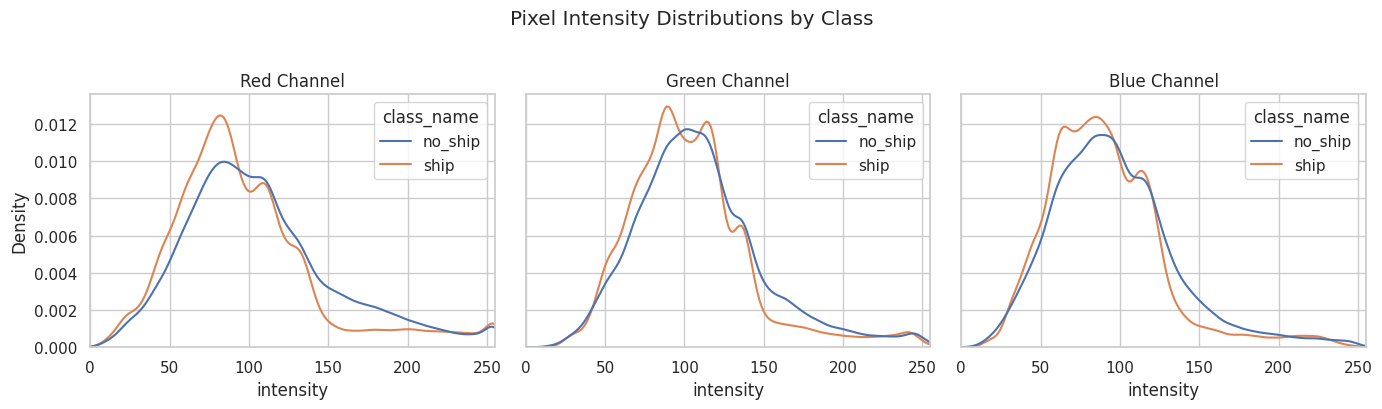

In [7]:
# Pixel intensity distributions by channel and class
sample_for_plot = metadata.copy()
channel_names = ["red", "green", "blue"]
rows = []
for label, class_name in [(0, "no_ship"), (1, "ship")]:
    imgs = X_uint8[y == label]
    # Subsample pixels for a readable plot.
    flat = imgs.reshape(-1, 3)
    take = rng.choice(flat.shape[0], size=min(100_000, flat.shape[0]), replace=False)
    for c, channel in enumerate(channel_names):
        values = flat[take, c]
        rows.append(pd.DataFrame({"intensity": values, "channel": channel, "class_name": class_name}))
pixel_plot_df = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, channel in zip(axes, channel_names):
    sns.kdeplot(data=pixel_plot_df[pixel_plot_df["channel"] == channel], x="intensity", hue="class_name", ax=ax, common_norm=False)
    ax.set_title(f"{channel.title()} Channel")
    ax.set_xlim(0, 255)
fig.suptitle("Pixel Intensity Distributions by Class", y=1.02)
track_artifact(save_fig("pixel_distributions.png", fig), "Pixel intensity distributions by class", "Report EDA section")
plt.show()

,scene_id,image_count,ship_count,ship_rate
423,20180712_180429_101b,39,11,0.282051
424,20180712_180755_0f2d,38,14,0.368421
51,20161218_180845_0e26,37,9,0.243243
404,20180708_180453_0f28,36,12,0.333333
117,20170515_180653_1007,34,12,0.352941
166,20170622_180819_1034,33,16,0.484848
406,20180708_180908_0f47,32,10,0.312500
61,20170129_181027_0e1f,30,8,0.266667
426,20180712_211331_0f06,30,10,0.333333
419,20180711_180503_1027,30,9,0.300000


Saved table: /content/drive/MyDrive/Project 2/outputs/top_scene_metadata_summary.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene_location_summary.png


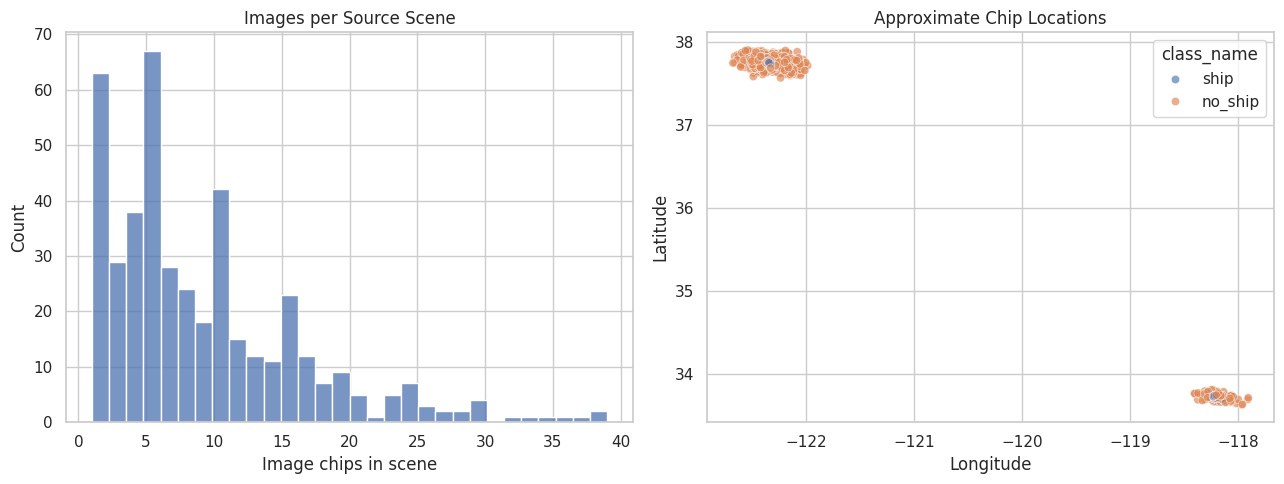

In [8]:
# Scene and location metadata summaries
scene_summary = metadata.groupby("scene_id").agg(
    image_count=("label", "size"),
    ship_count=("label", "sum"),
    ship_rate=("label", "mean"),
).reset_index().sort_values("image_count", ascending=False)
track_artifact(save_table(scene_summary.head(20), "top_scene_metadata_summary.csv"), "Top scenes by image count", "Report leakage/metadata discussion")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(scene_summary["image_count"], bins=30, ax=axes[0])
axes[0].set_title("Images per Source Scene")
axes[0].set_xlabel("Image chips in scene")

sns.scatterplot(data=metadata.sample(min(len(metadata), 2000), random_state=SEED), x="longitude", y="latitude", hue="class_name", alpha=0.65, ax=axes[1])
axes[1].set_title("Approximate Chip Locations")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
track_artifact(save_fig("scene_location_summary.png", fig), "Scene counts and chip locations", "Report EDA and limitations")
plt.show()

Saved figure: /content/drive/MyDrive/Project 2/outputs/modeling_pipeline.png


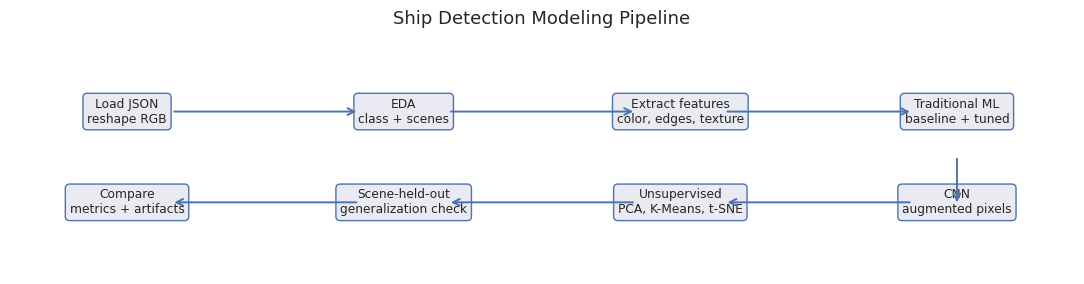

In [34]:
# Save a compact two-row project pipeline diagram as a figure
pipeline_steps = [
    ("Load JSON\nreshape RGB", 0.11, 0.68),
    ("EDA\nclass + scenes", 0.37, 0.68),
    ("Extract features\ncolor, edges, texture", 0.63, 0.68),
    ("Traditional ML\nbaseline + tuned", 0.89, 0.68),
    ("CNN\naugmented pixels", 0.89, 0.30),
    ("Unsupervised\nPCA, K-Means, t-SNE", 0.63, 0.30),
    ("Scene-held-out\ngeneralization check", 0.37, 0.30),
    ("Compare\nmetrics + artifacts", 0.11, 0.30),
]

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.axis("off")

for step, x, y_pos in pipeline_steps:
    ax.text(
        x,
        y_pos,
        step,
        ha="center",
        va="center",
        fontsize=8.8,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#EAEAF2", edgecolor="#4C72B0"),
        transform=ax.transAxes,
    )

for (_, x0, y0), (_, x1, y1) in zip(pipeline_steps[:-1], pipeline_steps[1:]):
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        xycoords=ax.transAxes,
        arrowprops=dict(arrowstyle="->", lw=1.4, color="#4C72B0", shrinkA=34, shrinkB=34),
    )

ax.set_title("Ship Detection Modeling Pipeline", fontsize=13, pad=8)
fig.subplots_adjust(left=0.03, right=0.97, top=0.84, bottom=0.10)
track_artifact(save_fig("modeling_pipeline.png", fig), "Project modeling pipeline diagram", "Report and presentation overview")
plt.show()

## 4. Hand-Crafted Feature Extraction

Traditional ML models use tabular features extracted from each image chip. The features include RGB and HSV channel statistics, edge density, texture descriptors, entropy, and Hu moments. The resulting table is saved for transparency and possible reuse.

In [10]:
from skimage import color, exposure, feature, filters, measure
from skimage.feature import graycomatrix, graycoprops
from tqdm.auto import tqdm

FEATURE_CACHE = OUTPUT_DIR / "handcrafted_features.csv"

def image_channel_stats(values, prefix):
    values = values.astype(np.float32)
    return {
        f"{prefix}_mean": float(values.mean()),
        f"{prefix}_std": float(values.std()),
        f"{prefix}_min": float(values.min()),
        f"{prefix}_max": float(values.max()),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_q25": float(np.quantile(values, 0.25)),
        f"{prefix}_q75": float(np.quantile(values, 0.75)),
    }

def extract_features_one(img_uint8):
    img_float = img_uint8.astype(np.float32) / 255.0
    gray = color.rgb2gray(img_float)
    gray_u8 = (gray * 255).astype(np.uint8)
    hsv = color.rgb2hsv(img_float)

    feats = {}
    for idx, name in enumerate(["red", "green", "blue"]):
        feats.update(image_channel_stats(img_uint8[:, :, idx], name))
    for idx, name in enumerate(["hue", "sat", "val"]):
        feats.update(image_channel_stats(hsv[:, :, idx], name))

    feats.update(image_channel_stats(gray_u8, "gray"))

    edges = feature.canny(gray, sigma=1.2)
    sobel = filters.sobel(gray)
    feats["canny_edge_density"] = float(edges.mean())
    feats["sobel_mean"] = float(sobel.mean())
    feats["sobel_std"] = float(sobel.std())
    feats["shannon_entropy"] = float(measure.shannon_entropy(gray_u8))

    # GLCM texture features on a quantized image keep computation stable and fast.
    gray_q = exposure.rescale_intensity(gray_u8, out_range=(0, 31)).astype(np.uint8)
    glcm = graycomatrix(gray_q, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=32, symmetric=True, normed=True)
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]:
        vals = graycoprops(glcm, prop)
        feats[f"glcm_{prop}_mean"] = float(vals.mean())
        feats[f"glcm_{prop}_std"] = float(vals.std())

    moments = cv2.moments(gray_u8)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    for i, value in enumerate(hu, start=1):
        feats[f"hu_moment_{i}"] = float(value)

    return feats

def build_feature_table(images_uint8, labels):
    rows = []
    for i, img in enumerate(tqdm(images_uint8, desc="Extracting features")):
        feats = extract_features_one(img)
        feats["label"] = int(labels[i])
        rows.append(feats)
    return pd.DataFrame(rows)

if FEATURE_CACHE.exists():
    features_df = pd.read_csv(FEATURE_CACHE)
    print(f"Loaded cached features: {FEATURE_CACHE}")
else:
    features_df = build_feature_table(X_uint8, y)
    features_df.to_csv(FEATURE_CACHE, index=False)
    print(f"Saved feature cache: {FEATURE_CACHE}")

track_artifact(FEATURE_CACHE, "Hand-crafted feature table", "Methods appendix and reproducibility")
print(features_df.shape)
display(features_df.head())

Loaded cached features: /content/drive/MyDrive/Project 2/outputs/handcrafted_features.csv
(4000, 73)


,red_mean,red_std,red_min,red_max,red_median,red_q25,red_q75,green_mean,green_std,green_min,...,glcm_ASM_mean,glcm_ASM_std,hu_moment_1,hu_moment_2,hu_moment_3,hu_moment_4,hu_moment_5,hu_moment_6,hu_moment_7,label
0,106.315781,46.321037,67.0,255.0,90.0,87.0,94.0,113.677498,39.484486,75.0,...,0.127229,0.005935,2.867184,8.554385,11.950389,11.895563,-12.0,11.999994,12.0,1
1,80.596252,24.917973,37.0,255.0,74.0,67.0,83.0,86.306877,20.763569,42.0,...,0.048303,0.005063,2.711303,7.999628,11.292563,11.057135,12.0,11.999741,12.0,1
2,135.374374,18.377310,82.0,255.0,130.0,127.0,134.0,145.231247,16.137873,84.0,...,0.131276,0.009511,2.939821,9.983184,11.988417,11.987453,12.0,-12.000000,-12.0,1
3,120.995155,43.528252,17.0,252.0,104.0,99.0,112.0,110.002342,21.671089,17.0,...,0.071383,0.005940,2.841695,8.986869,11.769551,11.897083,-12.0,11.999997,-12.0,1
4,108.253754,40.830162,25.0,255.0,98.0,81.0,112.0,108.238907,31.033789,26.0,...,0.042332,0.003640,2.839379,8.200370,11.437525,10.975459,12.0,-11.999696,12.0,1


In [11]:
# Prepare feature matrices for traditional ML
feature_cols = [c for c in features_df.columns if c != "label"]
X_features = features_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_features = X_features.fillna(X_features.median(numeric_only=True))

X_train_feat = X_features.iloc[train_idx].reset_index(drop=True)
X_test_feat = X_features.iloc[test_idx].reset_index(drop=True)

feature_summary = pd.DataFrame({
    "feature": feature_cols,
    "mean": X_features[feature_cols].mean().values,
    "std": X_features[feature_cols].std().values,
    "missing_after_fill": X_features[feature_cols].isna().sum().values,
})
track_artifact(save_table(feature_summary, "feature_summary.csv"), "Feature summary statistics", "Report feature engineering section")
print(f"Feature matrix: train={X_train_feat.shape}, test={X_test_feat.shape}")

,feature,mean,std,missing_after_fill
0,red_mean,105.038366,32.944070,0
1,red_std,31.809505,15.766518,0
2,red_min,47.748250,31.205309,0
3,red_max,231.678000,45.786717,0
4,red_median,97.219250,35.733640,0
...,...,...,...,...
67,hu_moment_3,11.338388,0.629337,0
68,hu_moment_4,11.322016,0.665591,0
69,hu_moment_5,-0.816000,11.973721,0
70,hu_moment_6,2.385082,11.758782,0


Saved table: /content/drive/MyDrive/Project 2/outputs/feature_summary.csv
Feature matrix: train=(3200, 72), test=(800, 72)


## 5. Untuned Benchmark Models

The course requirements call for basic, untuned benchmarks before tuning. Logistic Regression is the main baseline because it is simple, interpretable, and commonly covered in introductory ML. An untuned Random Forest is included as a second benchmark for context.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

MODEL_RESULTS = []
MODEL_PREDICTIONS = {}

def predict_scores(model, X_eval):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_eval)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-12)
    return model.predict(X_eval)

def evaluate_model(name, model, X_eval, y_true, prefix, positive_label="ship"):
    y_pred = model.predict(X_eval)
    y_score = predict_scores(model, X_eval)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }
    MODEL_RESULTS.append(metrics)
    MODEL_PREDICTIONS[name] = {"y_pred": y_pred, "y_score": y_score}

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["No ship", "Ship"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix")
    track_artifact(save_fig(f"{prefix}_confusion_matrix.png", fig), f"{name} confusion matrix", "Model comparison/report results")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(y_true, y_score, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"{name} ROC Curve")
    track_artifact(save_fig(f"{prefix}_roc_curve.png", fig), f"{name} ROC curve", "Model comparison/report results")
    plt.show()

    return metrics

def results_table(results=None):
    df = pd.DataFrame(results if results is not None else MODEL_RESULTS)
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    if not df.empty:
        df[metric_cols] = df[metric_cols].round(4)
        df = df.sort_values("f1", ascending=False).reset_index(drop=True)
    return df

Training Logistic Regression Baseline...
Saved figure: /content/drive/MyDrive/Project 2/outputs/logistic_regression_baseline_confusion_matrix.png


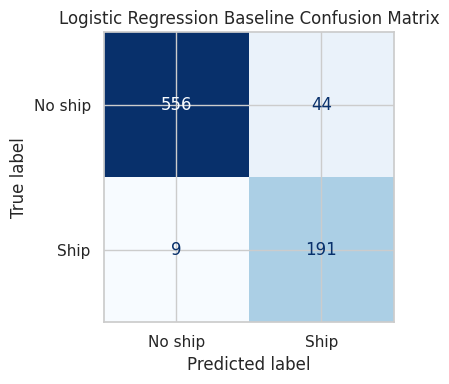

Saved figure: /content/drive/MyDrive/Project 2/outputs/logistic_regression_baseline_roc_curve.png


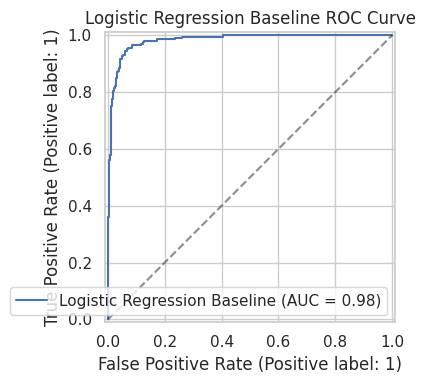

Training Untuned Random Forest Baseline...
Saved figure: /content/drive/MyDrive/Project 2/outputs/untuned_random_forest_baseline_confusion_matrix.png


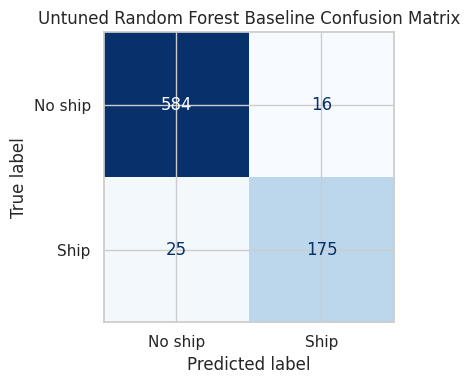

Saved figure: /content/drive/MyDrive/Project 2/outputs/untuned_random_forest_baseline_roc_curve.png


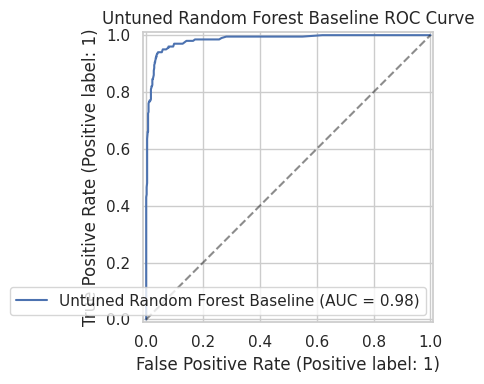

,model,accuracy,precision,recall,f1,roc_auc
0,Untuned Random Forest Baseline,0.9488,0.9162,0.875,0.8951,0.9841
1,Logistic Regression Baseline,0.9338,0.8128,0.955,0.8782,0.9823


Saved table: /content/drive/MyDrive/Project 2/outputs/baseline_model_metrics.csv


PosixPath('/content/drive/MyDrive/Project 2/outputs/baseline_model_metrics.csv')

In [13]:
# Train and evaluate untuned benchmarks
baseline_models = {
    "Logistic Regression Baseline": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "Untuned Random Forest Baseline": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
}

baseline_results = []
for name, model in baseline_models.items():
    print(f"Training {name}...")
    model.fit(X_train_feat, y_train)
    metrics = evaluate_model(name, model, X_test_feat, y_test, prefix=name.lower().replace(" ", "_").replace("/", "_"))
    baseline_results.append(metrics)

baseline_df = results_table(baseline_results)
track_artifact(save_table(baseline_df, "baseline_model_metrics.csv"), "Untuned benchmark metrics", "Benchmarking section")

## 6. Tuned Traditional Models

This section tunes Random Forest, RBF SVM, and gradient boosting. `RandomizedSearchCV` keeps the runtime practical in Colab while still showing real model selection. If XGBoost is unavailable, the notebook falls back to scikit-learn's histogram gradient boosting.

In [14]:
from scipy.stats import randint, loguniform, uniform
from sklearn.ensemble import HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    print(f"XGBoost unavailable, using HistGradientBoosting fallback: {exc}")
    XGBOOST_AVAILABLE = False

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_ITER = 15  # Increase to 30+ for a deeper search if runtime allows.

search_spaces = {
    "Tuned Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        {
            "n_estimators": randint(150, 600),
            "max_depth": [None, 6, 10, 14, 20],
            "min_samples_split": randint(2, 12),
            "min_samples_leaf": randint(1, 8),
            "max_features": ["sqrt", "log2", 0.5, None],
        },
    ),
    "Tuned RBF SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED)),
        ]),
        {
            "model__C": loguniform(0.1, 100),
            "model__gamma": loguniform(1e-4, 1),
        },
    ),
}

if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    search_spaces["Tuned XGBoost"] = (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        ),
        {
            "n_estimators": randint(100, 500),
            "max_depth": randint(2, 8),
            "learning_rate": loguniform(0.01, 0.2),
            "subsample": uniform(0.65, 0.35),
            "colsample_bytree": uniform(0.65, 0.35),
            "reg_lambda": loguniform(0.1, 10),
        },
    )
else:
    search_spaces["Tuned HistGradientBoosting"] = (
        HistGradientBoostingClassifier(random_state=SEED, class_weight="balanced"),
        {
            "learning_rate": loguniform(0.01, 0.2),
            "max_leaf_nodes": randint(10, 50),
            "max_iter": randint(100, 400),
            "l2_regularization": loguniform(1e-4, 1),
        },
    )


Searching Tuned Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_random_forest_confusion_matrix.png


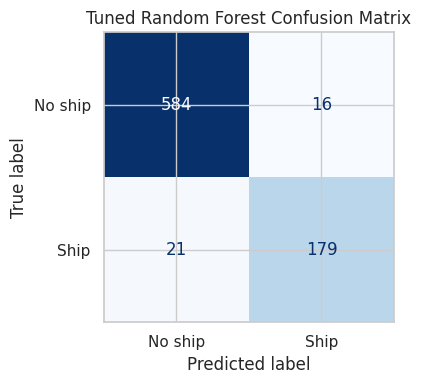

Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_random_forest_roc_curve.png


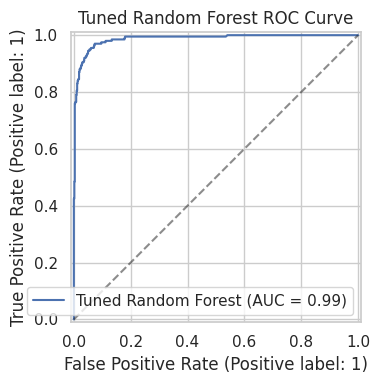


Searching Tuned RBF SVM...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_rbf_svm_confusion_matrix.png


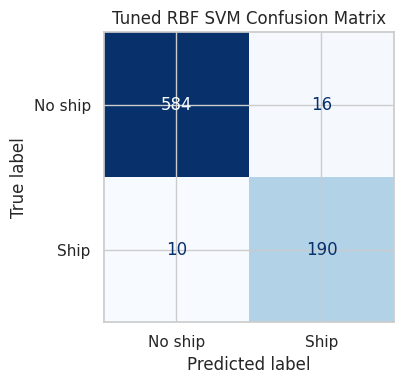

Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_rbf_svm_roc_curve.png


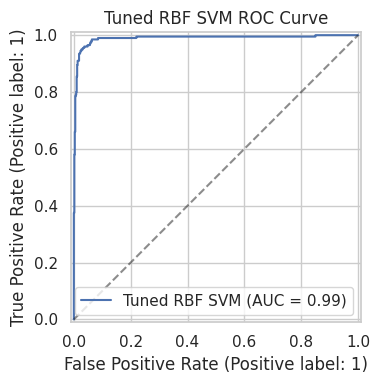


Searching Tuned XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_xgboost_confusion_matrix.png


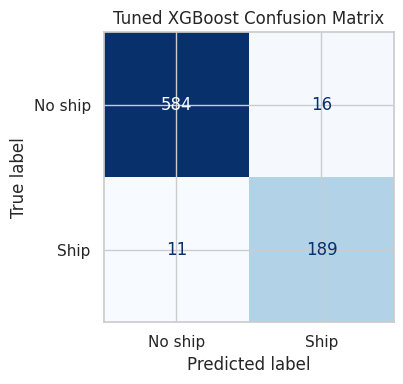

Saved figure: /content/drive/MyDrive/Project 2/outputs/tuned_xgboost_roc_curve.png


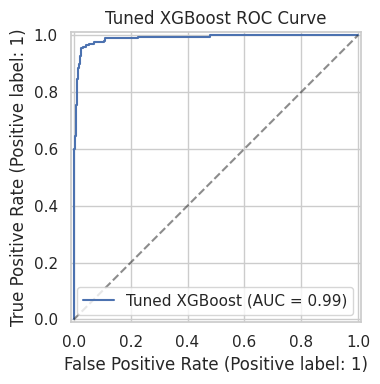

,model,best_cv_f1,best_params
0,Tuned XGBoost,0.941071,"{""colsample_bytree"": 0.945586847037353, ""learn..."
1,Tuned RBF SVM,0.930402,"{""model__C"": 15.702970884055384, ""model__gamma..."
2,Tuned Random Forest,0.915883,"{""max_depth"": 20, ""max_features"": 0.5, ""min_sa..."


Saved table: /content/drive/MyDrive/Project 2/outputs/tuned_cv_summary.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Tuned RBF SVM,0.9675,0.9223,0.950,0.9360,0.9891
1,Tuned XGBoost,0.9662,0.9220,0.945,0.9333,0.9893
2,Tuned Random Forest,0.9538,0.9179,0.895,0.9063,0.9872


Saved table: /content/drive/MyDrive/Project 2/outputs/tuned_model_metrics.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Tuned RBF SVM,0.9675,0.9223,0.950,0.9360,0.9891
1,Tuned XGBoost,0.9662,0.9220,0.945,0.9333,0.9893
2,Tuned Random Forest,0.9538,0.9179,0.895,0.9063,0.9872
3,Untuned Random Forest Baseline,0.9488,0.9162,0.875,0.8951,0.9841
4,Logistic Regression Baseline,0.9338,0.8128,0.955,0.8782,0.9823


Saved table: /content/drive/MyDrive/Project 2/outputs/traditional_model_comparison.csv


PosixPath('/content/drive/MyDrive/Project 2/outputs/traditional_model_comparison.csv')

In [15]:
# Run randomized searches and evaluate tuned models
TUNED_MODELS = {}
cv_rows = []
tuned_results = []

for name, (estimator, params) in search_spaces.items():
    print(f"\nSearching {name}...")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=N_ITER,
        scoring="f1",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X_train_feat, y_train)
    TUNED_MODELS[name] = search.best_estimator_

    cv_rows.append({
        "model": name,
        "best_cv_f1": search.best_score_,
        "best_params": json.dumps(search.best_params_, default=str),
    })

    metrics = evaluate_model(name, search.best_estimator_, X_test_feat, y_test, prefix=name.lower().replace(" ", "_").replace("/", "_"))
    tuned_results.append(metrics)

cv_summary_df = pd.DataFrame(cv_rows).sort_values("best_cv_f1", ascending=False).reset_index(drop=True)
track_artifact(save_table(cv_summary_df, "tuned_cv_summary.csv"), "Cross-validation summary and best hyperparameters", "Training and tuning section")

tuned_df = results_table(tuned_results)
track_artifact(save_table(tuned_df, "tuned_model_metrics.csv"), "Tuned traditional model metrics", "Training and tuning section")

traditional_comparison_df = results_table(MODEL_RESULTS)
track_artifact(save_table(traditional_comparison_df, "traditional_model_comparison.csv"), "Combined traditional model comparison", "Final model comparison")

Saved figure: /content/drive/MyDrive/Project 2/outputs/traditional_model_metric_comparison.png


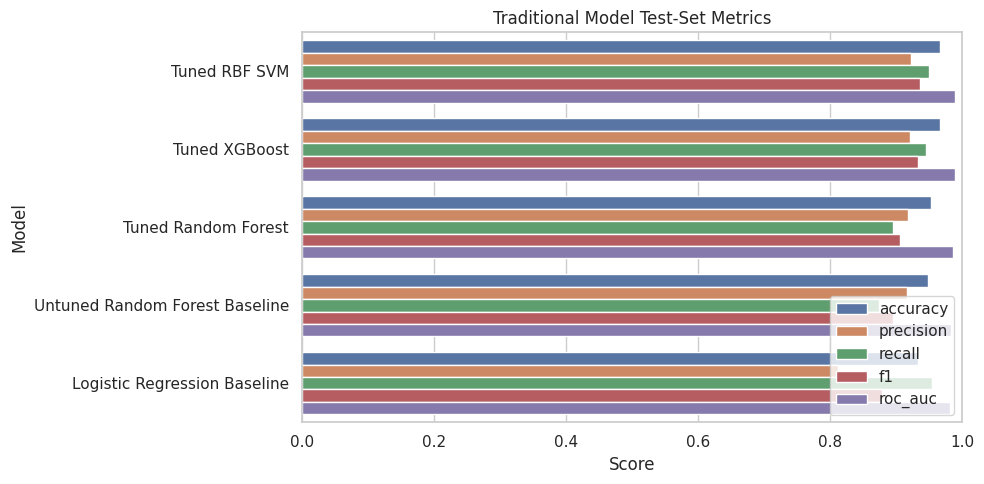

In [16]:
# Visual comparison of traditional model performance
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = traditional_comparison_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Traditional Model Test-Set Metrics")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("Model")
ax.legend(loc="lower right")
track_artifact(save_fig("traditional_model_metric_comparison.png", fig), "Traditional model metric comparison", "Report and presentation model results")
plt.show()

## 7. Unsupervised Analysis

The unsupervised section explores whether the hand-crafted feature space naturally separates ship and non-ship chips. PCA explains variance and gives interpretable low-dimensional projections. K-Means tests cluster agreement with labels. t-SNE provides a nonlinear 2D visualization for the report.

Saved table: /content/drive/MyDrive/Project 2/outputs/pca_explained_variance.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/pca_explained_variance.png


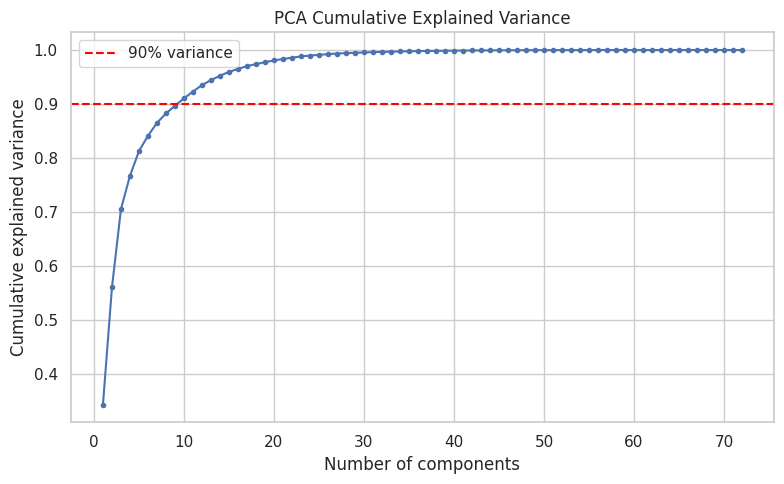

Components needed for 90% variance: 10


In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Standardize all feature rows for unsupervised analysis.
unsup_scaler = StandardScaler()
X_scaled_all = unsup_scaler.fit_transform(X_features)

pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled_all)
explained = np.cumsum(pca_full.explained_variance_ratio_)

pca_var_df = pd.DataFrame({
    "component": np.arange(1, len(explained) + 1),
    "cumulative_explained_variance": explained,
})
track_artifact(save_table(pca_var_df, "pca_explained_variance.csv", display_inline=False), "PCA explained variance table", "Unsupervised analysis section")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pca_var_df["component"], pca_var_df["cumulative_explained_variance"], marker="o", markersize=3)
ax.axhline(0.90, color="red", linestyle="--", label="90% variance")
ax.set_title("PCA Cumulative Explained Variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.legend()
track_artifact(save_fig("pca_explained_variance.png", fig), "PCA cumulative explained variance", "Report unsupervised analysis")
plt.show()

n_components_90 = int(np.searchsorted(explained, 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90}")

Saved figure: /content/drive/MyDrive/Project 2/outputs/pca_2d_by_label.png


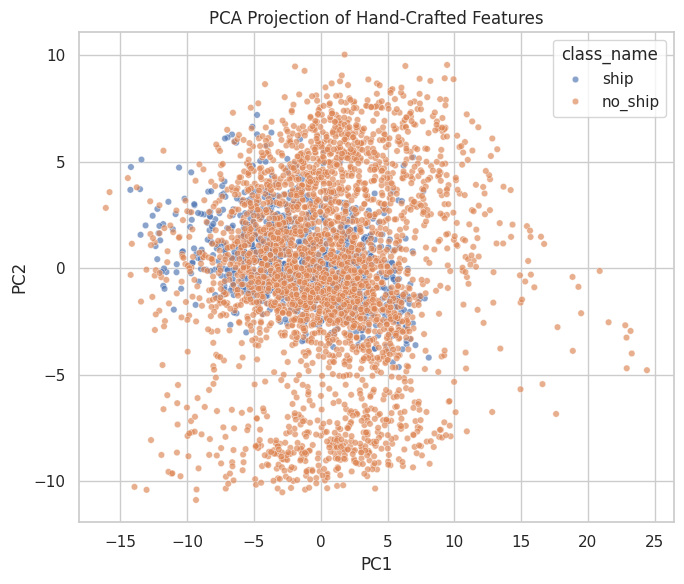

class_name,cluster,no_ship,ship
0,0,1370,620
1,1,1630,380


Saved table: /content/drive/MyDrive/Project 2/outputs/kmeans_cluster_crosstab.csv


,adjusted_rand_index,normalized_mutual_info
0,0.015434,0.016055


Saved table: /content/drive/MyDrive/Project 2/outputs/kmeans_cluster_metrics.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/kmeans_on_pca_projection.png


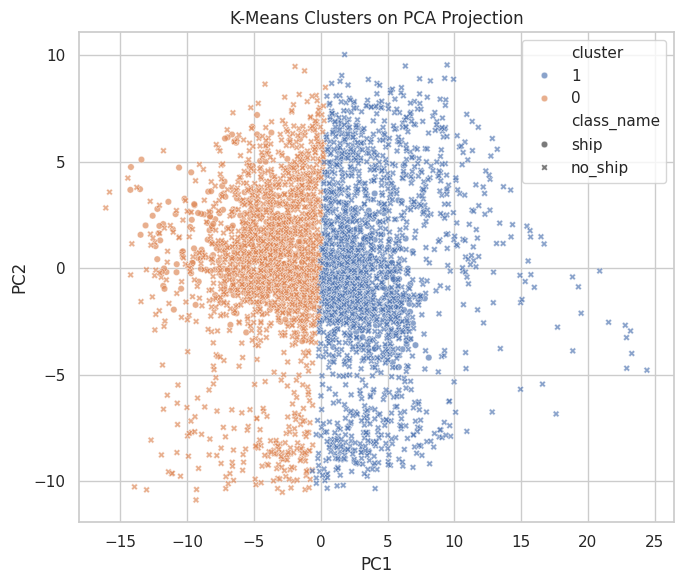

In [18]:
# PCA 2D projection and K-Means clustering
pca_2 = PCA(n_components=2, random_state=SEED)
X_pca_2 = pca_2.fit_transform(X_scaled_all)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "class_name": metadata["class_name"],
})

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="class_name", alpha=0.65, s=22, ax=ax)
ax.set_title("PCA Projection of Hand-Crafted Features")
track_artifact(save_fig("pca_2d_by_label.png", fig), "2D PCA projection colored by label", "Report unsupervised analysis")
plt.show()

kmeans = KMeans(n_clusters=2, n_init=30, random_state=SEED)
clusters = kmeans.fit_predict(X_scaled_all)
cluster_df = pd.crosstab(pd.Series(clusters, name="cluster"), metadata["class_name"])
cluster_metrics = pd.DataFrame([{
    "adjusted_rand_index": adjusted_rand_score(y, clusters),
    "normalized_mutual_info": normalized_mutual_info_score(y, clusters),
}])
track_artifact(save_table(cluster_df.reset_index(), "kmeans_cluster_crosstab.csv"), "K-Means cluster by class crosstab", "Unsupervised analysis section")
track_artifact(save_table(cluster_metrics, "kmeans_cluster_metrics.csv"), "K-Means label agreement metrics", "Unsupervised analysis section")

pca_plot_df["cluster"] = clusters.astype(str)
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="cluster", style="class_name", alpha=0.65, s=22, ax=ax)
ax.set_title("K-Means Clusters on PCA Projection")
track_artifact(save_fig("kmeans_on_pca_projection.png", fig), "K-Means clusters on PCA projection", "Report unsupervised analysis")
plt.show()

Saved figure: /content/drive/MyDrive/Project 2/outputs/tsne_feature_projection.png


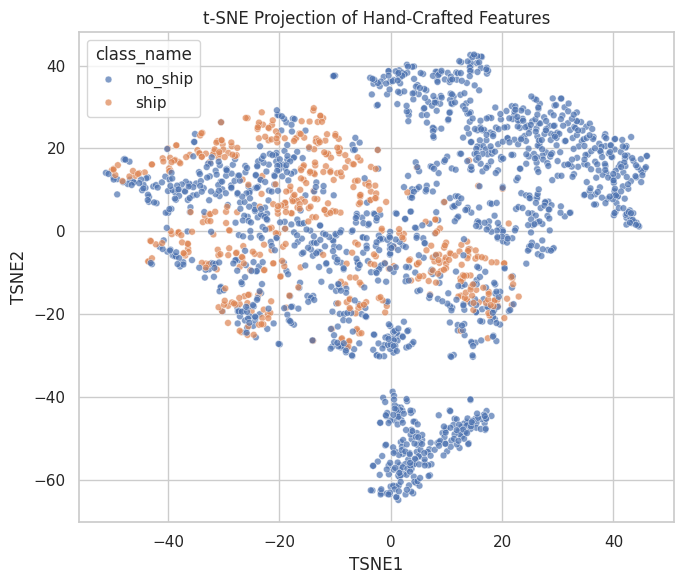

In [19]:
# t-SNE visualization on a standardized feature sample
TSNE_SAMPLE_SIZE = min(2000, len(X_scaled_all))
tsne_idx = rng.choice(np.arange(len(X_scaled_all)), size=TSNE_SAMPLE_SIZE, replace=False)

# PCA pre-reduction speeds up t-SNE and denoises high-dimensional features.
pca_for_tsne = PCA(n_components=min(30, X_scaled_all.shape[1]), random_state=SEED)
X_tsne_input = pca_for_tsne.fit_transform(X_scaled_all[tsne_idx])

tsne = TSNE(n_components=2, perplexity=35, learning_rate="auto", init="pca", random_state=SEED)
X_tsne = tsne.fit_transform(X_tsne_input)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "class_name": metadata.iloc[tsne_idx]["class_name"].values,
})

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="class_name", alpha=0.7, s=24, ax=ax)
ax.set_title("t-SNE Projection of Hand-Crafted Features")
track_artifact(save_fig("tsne_feature_projection.png", fig), "t-SNE feature projection", "Report unsupervised analysis and presentation")
plt.show()

Saved figure: /content/drive/MyDrive/Project 2/outputs/logistic_regression_pca_10_confusion_matrix.png


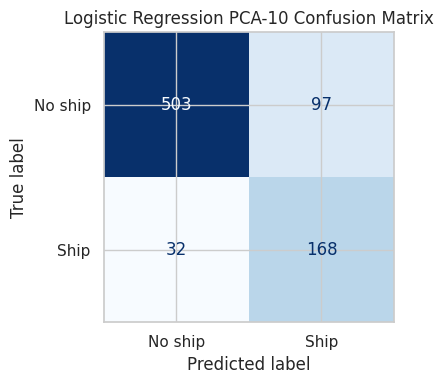

Saved figure: /content/drive/MyDrive/Project 2/outputs/logistic_regression_pca_10_roc_curve.png


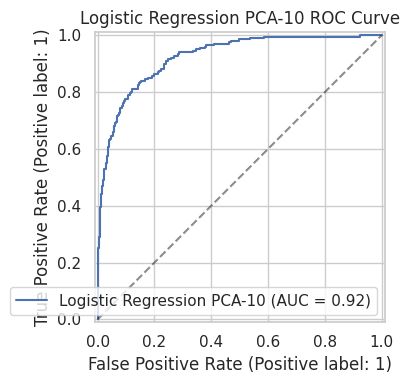

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression PCA-10,0.8388,0.634,0.84,0.7226,0.9229


Saved table: /content/drive/MyDrive/Project 2/outputs/pca_reduced_model_metrics.csv


PosixPath('/content/drive/MyDrive/Project 2/outputs/pca_reduced_model_metrics.csv')

In [20]:
# Optional extension: retrain the best traditional model on PCA-reduced features
from sklearn.base import clone

pca_components = min(n_components_90, X_train_feat.shape[1])
pca_feature_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=pca_components, random_state=SEED)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])

pca_feature_model.fit(X_train_feat, y_train)
pca_metrics = evaluate_model(
    f"Logistic Regression PCA-{pca_components}",
    pca_feature_model,
    X_test_feat,
    y_test,
    prefix=f"logistic_regression_pca_{pca_components}",
)

pca_extension_df = results_table([pca_metrics])
track_artifact(save_table(pca_extension_df, "pca_reduced_model_metrics.csv"), "PCA-reduced feature model metrics", "Optional extension/results comparison")

## 8. CNN on Raw Image Pixels

The CNN section gives the project a learned-representation comparison against hand-crafted features. In Colab with a GPU, the preferred model is ResNet18 transfer learning. If torchvision is not available, the notebook falls back to a deeper custom CNN with multiple convolution blocks, batch normalization, dropout, and global pooling.

The goal for this first pass is not to over-engineer the deep-learning side, but to train a model with enough depth and validation tracking to make the comparison interesting.

In [21]:
# PyTorch setup for CNN training
try:
    ensure_package("torch")
    ensure_package("torchvision")
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
    import torchvision.transforms as T
    from torchvision import models
    TORCH_AVAILABLE = True
except Exception as exc:
    TORCH_AVAILABLE = False
    print(f"PyTorch/torchvision unavailable; skip CNN or install manually. Error: {exc}")

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
else:
    device = None

Using device: cuda


In [22]:
# CNN datasets and loaders
if TORCH_AVAILABLE:
    cnn_train_idx, cnn_val_idx = train_test_split(
        np.arange(len(X_train_img)),
        test_size=0.20,
        random_state=SEED,
        stratify=y_train,
    )

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((96, 96)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.RandomRotation(degrees=20),
        T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    eval_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((96, 96)),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    class ShipsDataset(Dataset):
        def __init__(self, images_uint8, labels, transform=None):
            self.images = images_uint8
            self.labels = labels.astype(np.int64)
            self.transform = transform

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            img = self.images[idx]
            label = int(self.labels[idx])
            if self.transform is not None:
                img = self.transform(img)
            else:
                img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32) / 255.0
            return img, torch.tensor(label, dtype=torch.long)

    train_ds = ShipsDataset((X_train_img[cnn_train_idx] * 255).astype(np.uint8), y_train[cnn_train_idx], train_transform)
    val_ds = ShipsDataset((X_train_img[cnn_val_idx] * 255).astype(np.uint8), y_train[cnn_val_idx], eval_transform)
    test_ds = ShipsDataset((X_test_img * 255).astype(np.uint8), y_test, eval_transform)

    BATCH_SIZE = 64
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    print(f"CNN train/val/test sizes: {len(train_ds)}, {len(val_ds)}, {len(test_ds)}")

CNN train/val/test sizes: 2560, 640, 800


In [23]:
# CNN model definitions: ResNet18 preferred, custom CNN fallback available
if TORCH_AVAILABLE:
    class CustomShipCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.10),
                nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.15),
                nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.20),
                nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.35),
                nn.Linear(256, 64), nn.ReLU(),
                nn.Dropout(0.25),
                nn.Linear(64, 2),
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    def build_cnn_model(prefer_resnet=True):
        if prefer_resnet:
            try:
                weights = models.ResNet18_Weights.DEFAULT
                model = models.resnet18(weights=weights)
                # Freeze most of the backbone for a practical first pass.
                for param in model.parameters():
                    param.requires_grad = False
                for param in model.layer4.parameters():
                    param.requires_grad = True
                model.fc = nn.Sequential(
                    nn.Dropout(0.35),
                    nn.Linear(model.fc.in_features, 2),
                )
                print("Using ResNet18 transfer learning with layer4 + head trainable.")
                return model, "ResNet18 Transfer Learning"
            except Exception as exc:
                print(f"ResNet18 unavailable, falling back to custom CNN: {exc}")
        print("Using custom CNN fallback.")
        return CustomShipCNN(), "Custom CNN"

    cnn_model, cnn_model_name = build_cnn_model(prefer_resnet=True)
    cnn_model = cnn_model.to(device)
    trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in cnn_model.parameters())
    print(f"{cnn_model_name}: {trainable_params:,} trainable / {total_params:,} total parameters")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


Using ResNet18 transfer learning with layer4 + head trainable.
ResNet18 Transfer Learning: 8,394,754 trainable / 11,177,538 total parameters


In [ ]:
# CNN training and evaluation helpers
if TORCH_AVAILABLE:
    def run_epoch(model, loader, criterion, optimizer=None):
        training = optimizer is not None
        model.train(training)
        total_loss = 0.0
        all_labels, all_preds, all_scores = [], [], []

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                logits = model(xb)
                loss = criterion(logits, yb)
                if training:
                    loss.backward()
                    optimizer.step()

            probs = torch.softmax(logits.detach(), dim=1)[:, 1]
            preds = torch.argmax(logits.detach(), dim=1)
            total_loss += loss.item() * xb.size(0)
            all_labels.extend(yb.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(probs.cpu().numpy())

        labels = np.asarray(all_labels)
        preds = np.asarray(all_preds)
        scores = np.asarray(all_scores)
        metrics = {
            "loss": total_loss / len(loader.dataset),
            "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, zero_division=0),
            "recall": recall_score(labels, preds, zero_division=0),
            "f1": f1_score(labels, preds, zero_division=0),
            "roc_auc": roc_auc_score(labels, scores),
        }
        return metrics, labels, preds, scores

    def train_cnn(model, train_loader, val_loader, epochs=25, patience=6):
        class_counts_train = np.bincount(y_train[cnn_train_idx], minlength=2)
        class_weights = class_counts_train.sum() / (2 * np.maximum(class_counts_train, 1))
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
        optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

        best_state = None
        best_f1 = -np.inf
        bad_epochs = 0
        history = []

        for epoch in range(1, epochs + 1):
            train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_metrics, *_ = run_epoch(model, val_loader, criterion, optimizer=None)
            scheduler.step(val_metrics["f1"])

            row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}}
            history.append(row)
            print(f"Epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} f1 {train_metrics['f1']:.4f} | val loss {val_metrics['loss']:.4f} f1 {val_metrics['f1']:.4f} auc {val_metrics['roc_auc']:.4f}")

            if val_metrics["f1"] > best_f1:
                best_f1 = val_metrics["f1"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print(f"Early stopping after {epoch} epochs.")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)
        return pd.DataFrame(history), model

Epoch 01 | train loss 0.2585 f1 0.7871 | val loss 0.0811 f1 0.9345 auc 0.9979
Epoch 02 | train loss 0.0807 f1 0.9429 | val loss 0.0395 f1 0.9755 auc 0.9997
Epoch 03 | train loss 0.0402 f1 0.9760 | val loss 0.0296 f1 0.9816 auc 0.9998
Epoch 04 | train loss 0.0315 f1 0.9837 | val loss 0.0211 f1 0.9938 auc 1.0000
Epoch 05 | train loss 0.0212 f1 0.9838 | val loss 0.0190 f1 0.9846 auc 1.0000
Epoch 06 | train loss 0.0212 f1 0.9876 | val loss 0.0106 f1 0.9938 auc 1.0000
Epoch 07 | train loss 0.0203 f1 0.9845 | val loss 0.0127 f1 0.9877 auc 1.0000
Epoch 08 | train loss 0.0218 f1 0.9845 | val loss 0.0155 f1 0.9816 auc 1.0000
Epoch 09 | train loss 0.0125 f1 0.9914 | val loss 0.0138 f1 0.9846 auc 1.0000
Epoch 10 | train loss 0.0165 f1 0.9899 | val loss 0.0101 f1 0.9907 auc 1.0000
Epoch 11 | train loss 0.0089 f1 0.9945 | val loss 0.0078 f1 0.9938 auc 1.0000
Epoch 12 | train loss 0.0093 f1 0.9930 | val loss 0.0078 f1 0.9938 auc 1.0000
Early stopping after 12 epochs.
Saved table: /content/drive/MyDr

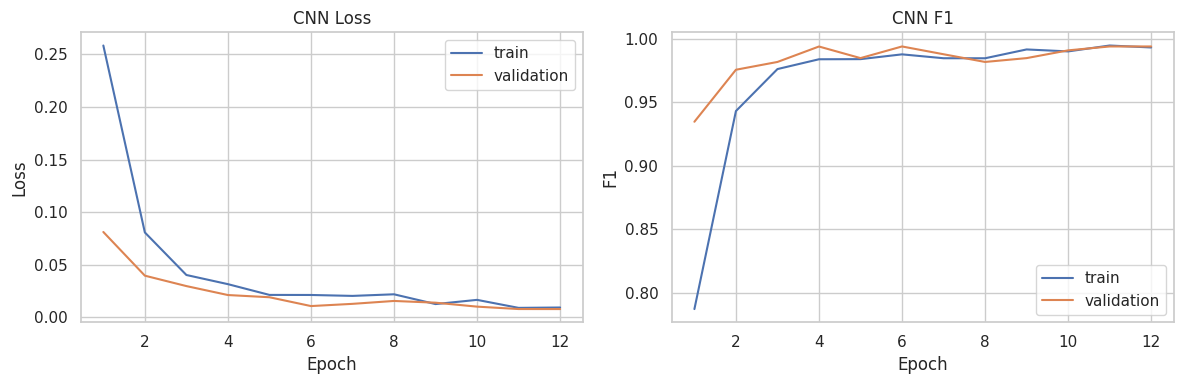

In [25]:
# Train the CNN. Increase CNN_EPOCHS if you want a deeper later pass.
CNN_EPOCHS = 25
CNN_PATIENCE = 6
RUN_CNN = TORCH_AVAILABLE

if RUN_CNN:
    history_df, cnn_model = train_cnn(cnn_model, train_loader, val_loader, epochs=CNN_EPOCHS, patience=CNN_PATIENCE)
    track_artifact(save_table(history_df, "cnn_training_history.csv", display_inline=False), "CNN training history", "CNN results and learning curve discussion")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
    axes[0].set_title("CNN Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_f1"], label="validation")
    axes[1].set_title("CNN F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1")
    axes[1].legend()
    track_artifact(save_fig("cnn_training_curves.png", fig), "CNN training and validation curves", "Report CNN section and presentation")
    plt.show()
else:
    print("CNN training skipped because PyTorch is unavailable.")

,model,accuracy,precision,recall,f1,roc_auc
0,ResNet18 Transfer Learning,0.9912,0.9801,0.985,0.9825,0.999


Saved table: /content/drive/MyDrive/Project 2/outputs/cnn_test_metrics.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/cnn_confusion_matrix.png


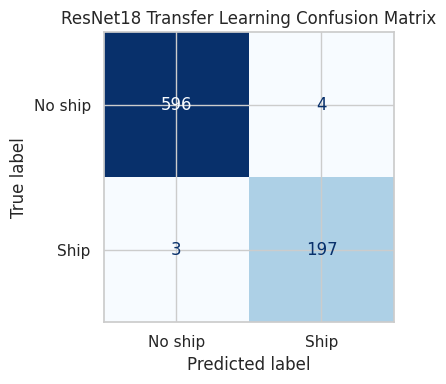

Saved figure: /content/drive/MyDrive/Project 2/outputs/cnn_roc_curve.png


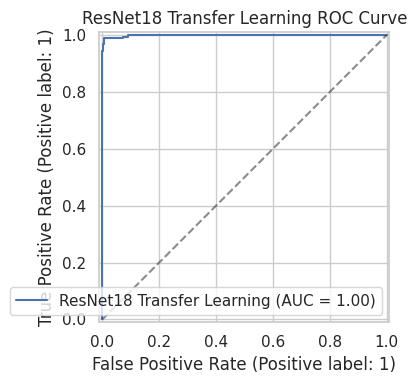

In [26]:
# Evaluate CNN on the held-out test set
if RUN_CNN:
    class_counts_train = np.bincount(y_train[cnn_train_idx], minlength=2)
    class_weights = class_counts_train.sum() / (2 * np.maximum(class_counts_train, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
    test_metrics_raw, test_labels, test_preds, test_scores = run_epoch(cnn_model, test_loader, criterion, optimizer=None)

    cnn_metrics = {"model": cnn_model_name, **{k: v for k, v in test_metrics_raw.items() if k != "loss"}}
    MODEL_RESULTS.append(cnn_metrics)
    MODEL_PREDICTIONS[cnn_model_name] = {"y_pred": test_preds, "y_score": test_scores}

    cnn_metrics_df = results_table([cnn_metrics])
    track_artifact(save_table(cnn_metrics_df, "cnn_test_metrics.csv"), "CNN held-out test metrics", "CNN results section")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(test_labels, test_preds, display_labels=["No ship", "Ship"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{cnn_model_name} Confusion Matrix")
    track_artifact(save_fig("cnn_confusion_matrix.png", fig), "CNN confusion matrix", "CNN results section")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(test_labels, test_scores, ax=ax, name=cnn_model_name)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"{cnn_model_name} ROC Curve")
    track_artifact(save_fig("cnn_roc_curve.png", fig), "CNN ROC curve", "CNN results section and presentation")
    plt.show()
else:
    cnn_metrics_df = pd.DataFrame()
    print("No CNN metrics because CNN training was skipped.")

Saved figure: /content/drive/MyDrive/Project 2/outputs/cnn_prediction_examples.png


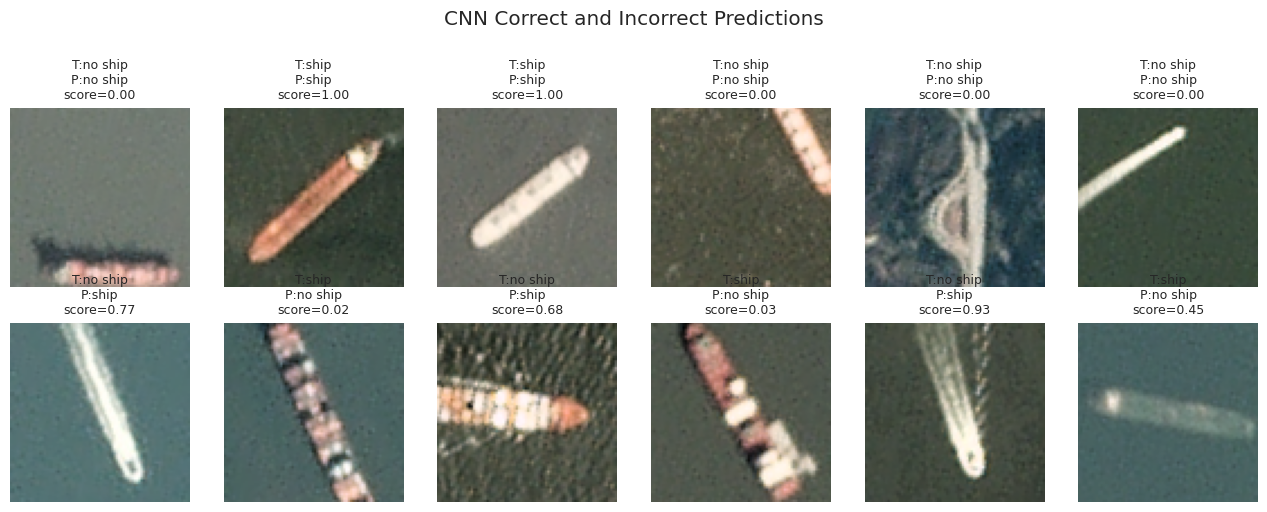

In [27]:
# Visualize selected correct and incorrect CNN predictions
if RUN_CNN:
    correct = np.where(test_preds == test_labels)[0]
    incorrect = np.where(test_preds != test_labels)[0]
    chosen_correct = rng.choice(correct, size=min(6, len(correct)), replace=False) if len(correct) else np.array([], dtype=int)
    chosen_incorrect = rng.choice(incorrect, size=min(6, len(incorrect)), replace=False) if len(incorrect) else np.array([], dtype=int)
    chosen = np.concatenate([chosen_correct, chosen_incorrect])

    fig, axes = plt.subplots(2, 6, figsize=(13, 5))
    axes = axes.ravel()
    for ax_i, ax in enumerate(axes):
        if ax_i >= len(chosen):
            ax.axis("off")
            continue
        idx = chosen[ax_i]
        ax.imshow((X_test_img[idx] * 255).astype(np.uint8))
        ax.axis("off")
        true_name = "ship" if test_labels[idx] == 1 else "no ship"
        pred_name = "ship" if test_preds[idx] == 1 else "no ship"
        ax.set_title(f"T:{true_name}\nP:{pred_name}\nscore={test_scores[idx]:.2f}", fontsize=9)
    fig.suptitle("CNN Correct and Incorrect Predictions", y=1.02)
    track_artifact(save_fig("cnn_prediction_examples.png", fig), "CNN correct/incorrect prediction examples", "Presentation model behavior slide")
    plt.show()

## 9. Final Model Comparison and Report Assets

This section combines all supervised results into a final comparison table and figure. The final cells also create an artifact index and presentation talking points so the notebook can serve as the source of truth for the written report and slides.

,model,accuracy,precision,recall,f1,roc_auc
0,ResNet18 Transfer Learning,0.9912,0.9801,0.985,0.9825,0.9990
1,Tuned RBF SVM,0.9675,0.9223,0.950,0.9360,0.9891
2,Tuned XGBoost,0.9662,0.9220,0.945,0.9333,0.9893
3,Tuned Random Forest,0.9538,0.9179,0.895,0.9063,0.9872
4,Untuned Random Forest Baseline,0.9488,0.9162,0.875,0.8951,0.9841
5,Logistic Regression Baseline,0.9338,0.8128,0.955,0.8782,0.9823
6,Logistic Regression PCA-10,0.8388,0.6340,0.840,0.7226,0.9229


Saved table: /content/drive/MyDrive/Project 2/outputs/final_supervised_model_comparison.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/final_model_metric_comparison.png


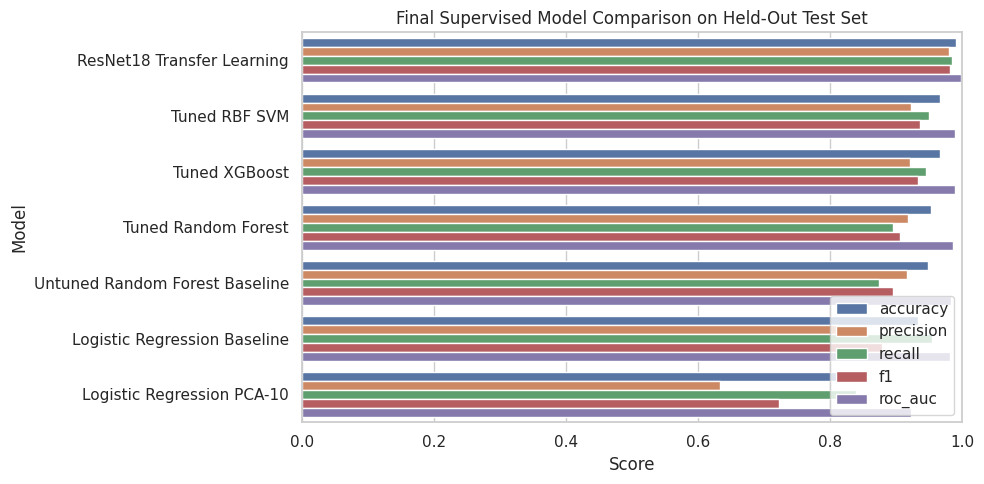

Saved figure: /content/drive/MyDrive/Project 2/outputs/final_roc_overlay.png


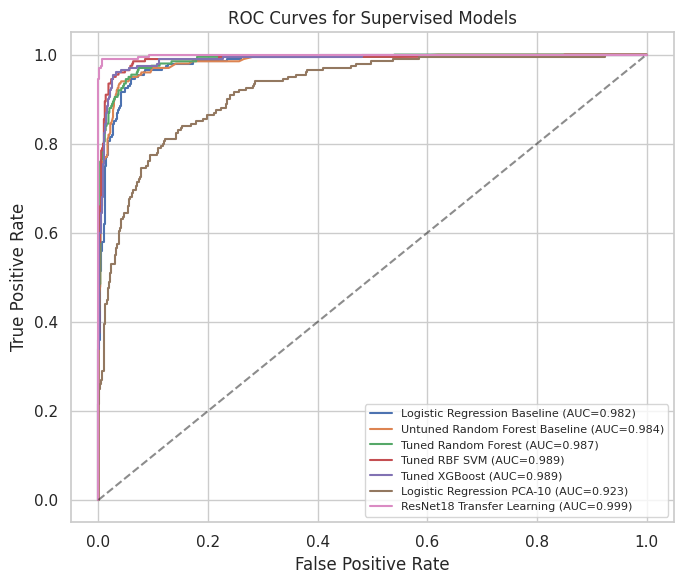

In [28]:
# Final supervised model comparison
final_results_df = results_table(MODEL_RESULTS)
track_artifact(save_table(final_results_df, "final_supervised_model_comparison.csv"), "Final supervised model comparison", "Report conclusions and presentation results")

fig, ax = plt.subplots(figsize=(10, 5))
final_plot_df = final_results_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=final_plot_df, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Final Supervised Model Comparison on Held-Out Test Set")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("Model")
ax.legend(loc="lower right")
track_artifact(save_fig("final_model_metric_comparison.png", fig), "Final supervised model comparison chart", "Presentation final results slide")
plt.show()

# Overlay ROC curves for all supervised models.
fig, ax = plt.subplots(figsize=(7, 6))
for name, pred in MODEL_PREDICTIONS.items():
    fpr, tpr, _ = roc_curve(y_test, pred["y_score"])
    auc = roc_auc_score(y_test, pred["y_score"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("ROC Curves for Supervised Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)
track_artifact(save_fig("final_roc_overlay.png", fig), "Final ROC overlay", "Report and presentation final comparison")
plt.show()

## 10. Scene-Held-Out Generalization Check

The proposal-aligned stratified split preserves the 1:3 ship/no-ship class ratio, but it allows chips from the same source scene to appear in both train and test sets. That makes the original results useful for comparing methods on the same split, but potentially optimistic for real-world generalization.

This section adds a stricter evaluation: all chips from a source `scene_id` are assigned entirely to either train or test. Augmentation can improve CNN robustness, but it does not solve source-scene overlap by itself. The grouped split is the actual leakage-control step; augmentation is applied only to grouped training images.

In [29]:
# Scene-held-out train/test datasets
# These indices were created in the data-prep section with GroupShuffleSplit by scene_id.
X_group_train_feat = X_features.iloc[group_train_idx].reset_index(drop=True)
X_group_test_feat = X_features.iloc[group_test_idx].reset_index(drop=True)
y_group_train = y[group_train_idx]
y_group_test = y[group_test_idx]

X_group_train_img = X[group_train_idx]
X_group_test_img = X[group_test_idx]
X_group_train_uint8 = X_uint8[group_train_idx]
X_group_test_uint8 = X_uint8[group_test_idx]
meta_group_train = metadata.iloc[group_train_idx].reset_index(drop=True)
meta_group_test = metadata.iloc[group_test_idx].reset_index(drop=True)

scene_heldout_summary = pd.DataFrame([
    split_summary("scene_heldout_used", group_train_idx, group_test_idx),
])
track_artifact(
    save_table(scene_heldout_summary, "scene_heldout_split_summary.csv"),
    "Scene-held-out train/test split summary",
    "Report generalization and limitations section",
)

print(f"Scene-held-out feature matrices: train={X_group_train_feat.shape}, test={X_group_test_feat.shape}")
print(f"Scene-held-out image tensors: train={X_group_train_img.shape}, test={X_group_test_img.shape}")
print(f"Scene overlap: {scene_heldout_summary.loc[0, 'scene_overlap']}")

,split,train_n,test_n,train_ship_rate,test_ship_rate,train_unique_scenes,test_unique_scenes,scene_overlap
0,scene_heldout_used,3196,804,0.24562,0.267413,347,87,0


Saved table: /content/drive/MyDrive/Project 2/outputs/scene_heldout_split_summary.csv
Scene-held-out feature matrices: train=(3196, 72), test=(804, 72)
Scene-held-out image tensors: train=(3196, 80, 80, 3), test=(804, 80, 80, 3)
Scene overlap: 0


Training Scene-Held-Out Logistic Regression...
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_logistic_regression_confusion_matrix.png


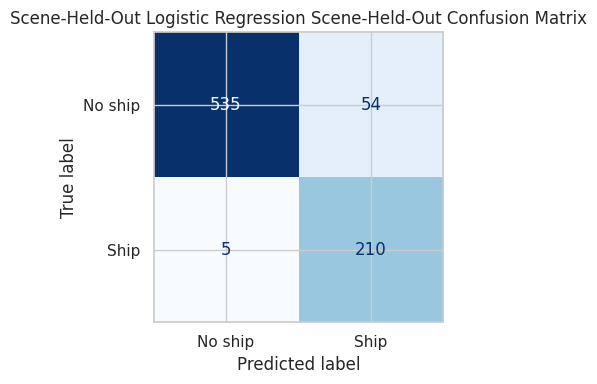

Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_logistic_regression_roc_curve.png


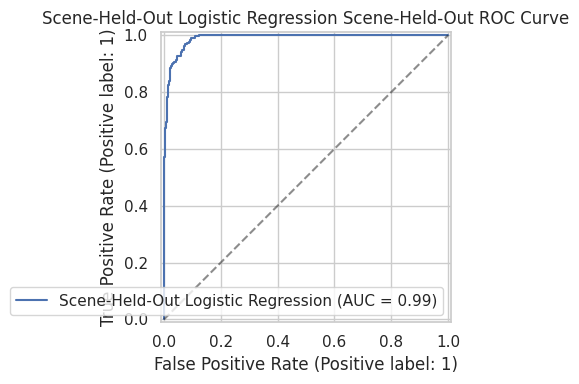


Searching Scene-Held-Out Tuned RBF SVM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_tuned_rbf_svm_confusion_matrix.png


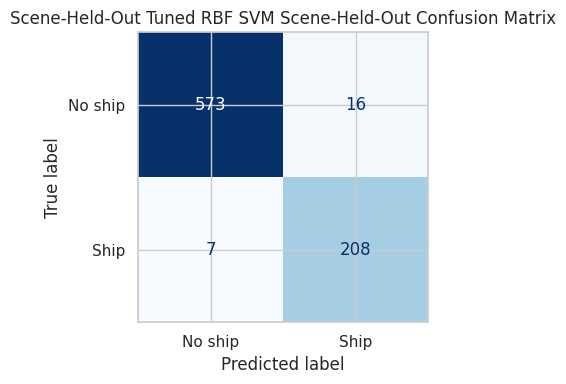

Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_tuned_rbf_svm_roc_curve.png


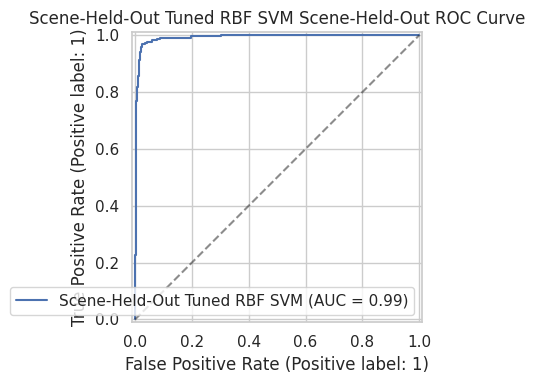


Searching Scene-Held-Out Tuned XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_tuned_xgboost_confusion_matrix.png


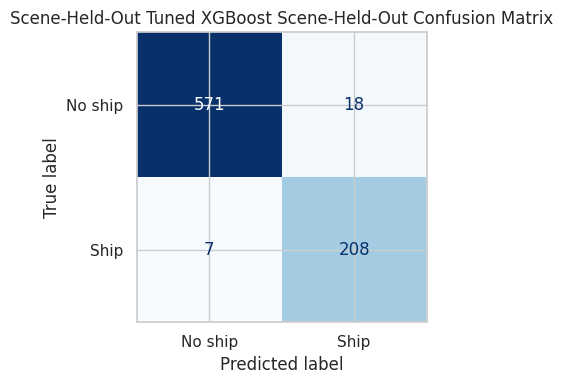

Saved figure: /content/drive/MyDrive/Project 2/outputs/scene-held-out_tuned_xgboost_roc_curve.png


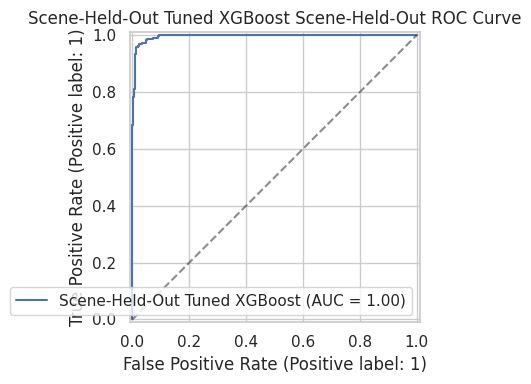

,model,best_cv_f1,best_params
0,Scene-Held-Out Tuned RBF SVM,0.934899,"{""model__C"": 15.702970884055384, ""model__gamma..."
1,Scene-Held-Out Tuned XGBoost,0.933826,"{""colsample_bytree"": 0.9325398470083344, ""lear..."


Saved table: /content/drive/MyDrive/Project 2/outputs/scene_heldout_traditional_cv_summary.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Scene-Held-Out Tuned RBF SVM,0.9714,0.9286,0.9674,0.9476,0.9924
1,Scene-Held-Out Tuned XGBoost,0.9689,0.9204,0.9674,0.9433,0.9959
2,Scene-Held-Out Logistic Regression,0.9266,0.7955,0.9767,0.8768,0.9892


Saved table: /content/drive/MyDrive/Project 2/outputs/scene_heldout_traditional_metrics.csv


PosixPath('/content/drive/MyDrive/Project 2/outputs/scene_heldout_traditional_metrics.csv')

In [30]:
# Scene-held-out traditional model evaluation
SCENE_HELDOUT_RESULTS = []
SCENE_HELDOUT_PREDICTIONS = {}

def evaluate_scene_heldout_model(name, model, X_eval, y_true, prefix):
    y_pred = model.predict(X_eval)
    y_score = predict_scores(model, X_eval)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }
    SCENE_HELDOUT_RESULTS.append(metrics)
    SCENE_HELDOUT_PREDICTIONS[name] = {"y_pred": y_pred, "y_score": y_score}

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["No ship", "Ship"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name} Scene-Held-Out Confusion Matrix")
    track_artifact(save_fig(f"{prefix}_confusion_matrix.png", fig), f"{name} scene-held-out confusion matrix", "Scene-held-out model comparison")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(y_true, y_score, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"{name} Scene-Held-Out ROC Curve")
    track_artifact(save_fig(f"{prefix}_roc_curve.png", fig), f"{name} scene-held-out ROC curve", "Scene-held-out model comparison")
    plt.show()

    return metrics

def scene_results_table(results=None):
    df = pd.DataFrame(results if results is not None else SCENE_HELDOUT_RESULTS)
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    if not df.empty:
        df[metric_cols] = df[metric_cols].round(4)
        df = df.sort_values("f1", ascending=False).reset_index(drop=True)
    return df

scene_traditional_models = {
    "Scene-Held-Out Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
}

# Rerun compact train-only hyperparameter searches for the two strongest traditional model families.
scene_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCENE_N_ITER = 10
scene_search_spaces = {
    "Scene-Held-Out Tuned RBF SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED)),
        ]),
        {
            "model__C": loguniform(0.1, 100),
            "model__gamma": loguniform(1e-4, 1),
        },
    )
}

if XGBOOST_AVAILABLE:
    scene_scale_pos_weight = (y_group_train == 0).sum() / max((y_group_train == 1).sum(), 1)
    scene_search_spaces["Scene-Held-Out Tuned XGBoost"] = (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            scale_pos_weight=scene_scale_pos_weight,
        ),
        {
            "n_estimators": randint(100, 400),
            "max_depth": randint(2, 7),
            "learning_rate": loguniform(0.01, 0.2),
            "subsample": uniform(0.70, 0.30),
            "colsample_bytree": uniform(0.70, 0.30),
            "reg_lambda": loguniform(0.1, 10),
        },
    )

scene_cv_rows = []

for name, model in scene_traditional_models.items():
    print(f"Training {name}...")
    model.fit(X_group_train_feat, y_group_train)
    evaluate_scene_heldout_model(name, model, X_group_test_feat, y_group_test, prefix=name.lower().replace(" ", "_").replace("/", "_"))

for name, (estimator, params) in scene_search_spaces.items():
    print(f"\nSearching {name}...")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=SCENE_N_ITER,
        scoring="f1",
        cv=scene_cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X_group_train_feat, y_group_train)
    scene_cv_rows.append({
        "model": name,
        "best_cv_f1": search.best_score_,
        "best_params": json.dumps(search.best_params_, default=str),
    })
    evaluate_scene_heldout_model(name, search.best_estimator_, X_group_test_feat, y_group_test, prefix=name.lower().replace(" ", "_").replace("/", "_"))

scene_cv_summary_df = pd.DataFrame(scene_cv_rows).sort_values("best_cv_f1", ascending=False).reset_index(drop=True)
track_artifact(save_table(scene_cv_summary_df, "scene_heldout_traditional_cv_summary.csv"), "Scene-held-out traditional model CV summary", "Scene-held-out tuning section")

scene_traditional_df = scene_results_table()
track_artifact(save_table(scene_traditional_df, "scene_heldout_traditional_metrics.csv"), "Scene-held-out traditional model metrics", "Scene-held-out model comparison")

Scene CNN train/val scene overlap: 0
Scene-held-out CNN train/val/test sizes: 2460, 736, 804
Using ResNet18 transfer learning with layer4 + head trainable.
Epoch 01 | train loss 0.3067 f1 0.7491 | val loss 0.1568 f1 0.9209 auc 0.9942
Epoch 02 | train loss 0.1498 f1 0.8882 | val loss 0.0795 f1 0.9540 auc 0.9985
Epoch 03 | train loss 0.1253 f1 0.9022 | val loss 0.0745 f1 0.9567 auc 0.9997
Epoch 04 | train loss 0.0990 f1 0.9206 | val loss 0.0496 f1 0.9803 auc 0.9999
Epoch 05 | train loss 0.0809 f1 0.9386 | val loss 0.0362 f1 0.9827 auc 0.9998
Epoch 06 | train loss 0.0603 f1 0.9480 | val loss 0.0330 f1 0.9876 auc 0.9999
Epoch 07 | train loss 0.0634 f1 0.9609 | val loss 0.0182 f1 0.9900 auc 1.0000
Epoch 08 | train loss 0.0609 f1 0.9525 | val loss 0.0210 f1 0.9876 auc 0.9999
Epoch 09 | train loss 0.0534 f1 0.9576 | val loss 0.0147 f1 0.9925 auc 1.0000
Epoch 10 | train loss 0.0616 f1 0.9495 | val loss 0.0201 f1 0.9950 auc 0.9998
Epoch 11 | train loss 0.0637 f1 0.9526 | val loss 0.0135 f1 0.99

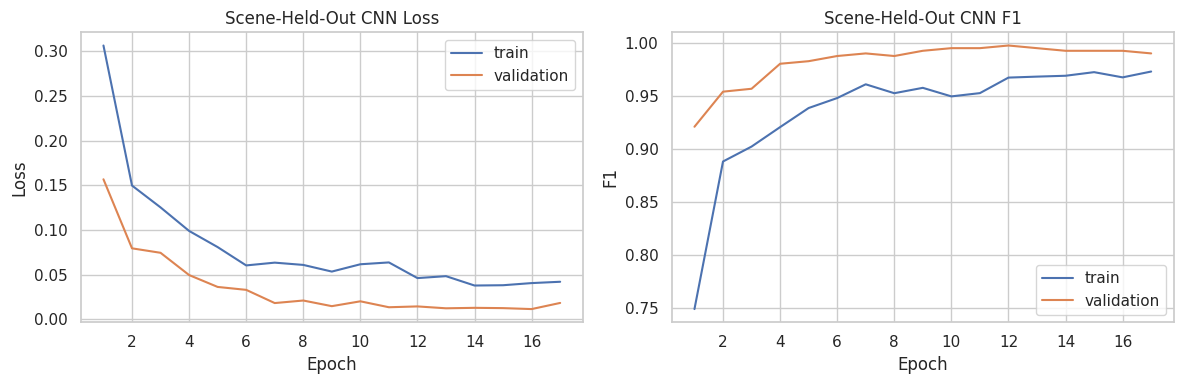

,model,accuracy,precision,recall,f1,roc_auc
0,Scene-Held-Out ResNet18 Transfer Learning,0.9988,1.0,0.9953,0.9977,1.0


Saved table: /content/drive/MyDrive/Project 2/outputs/scene_heldout_cnn_test_metrics.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene_heldout_cnn_confusion_matrix.png


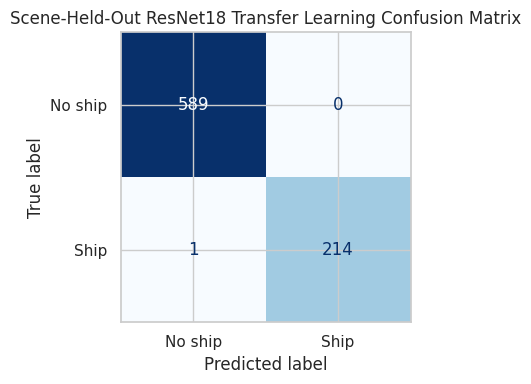

Saved figure: /content/drive/MyDrive/Project 2/outputs/scene_heldout_cnn_roc_curve.png


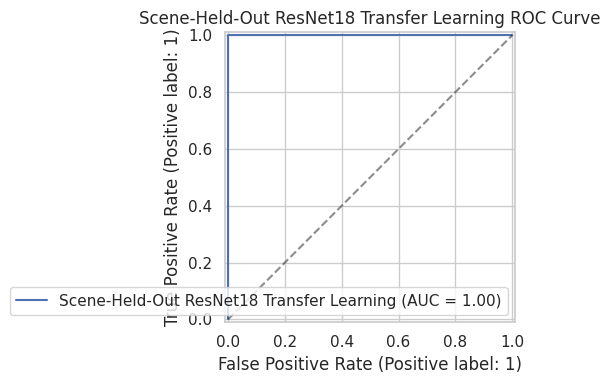

In [31]:
# Scene-held-out CNN evaluation with scene-safe validation and train-only augmentation
RUN_SCENE_HELDOUT_CNN = TORCH_AVAILABLE
SCENE_CNN_EPOCHS = 20
SCENE_CNN_PATIENCE = 5

if RUN_SCENE_HELDOUT_CNN:
    # Split grouped training scenes into train/validation scenes with no scene overlap.
    scene_val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
    scene_cnn_train_local_idx, scene_cnn_val_local_idx = next(
        scene_val_splitter.split(
            X_group_train_img,
            y_group_train,
            groups=meta_group_train["scene_id"].values,
        )
    )

    scene_train_scenes = set(meta_group_train.iloc[scene_cnn_train_local_idx]["scene_id"])
    scene_val_scenes = set(meta_group_train.iloc[scene_cnn_val_local_idx]["scene_id"])
    print(f"Scene CNN train/val scene overlap: {len(scene_train_scenes & scene_val_scenes)}")

    scene_train_transform = T.Compose([
        T.ToPILImage(),
        T.RandomResizedCrop((96, 96), scale=(0.80, 1.00), ratio=(0.90, 1.10)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.RandomRotation(degrees=30),
        T.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.90, 1.10), shear=5),
        T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.03),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std),
        T.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    ])

    scene_eval_transform = T.Compose([
        T.ToPILImage(),
        T.Resize((96, 96)),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    scene_train_ds = ShipsDataset(X_group_train_uint8[scene_cnn_train_local_idx], y_group_train[scene_cnn_train_local_idx], scene_train_transform)
    scene_val_ds = ShipsDataset(X_group_train_uint8[scene_cnn_val_local_idx], y_group_train[scene_cnn_val_local_idx], scene_eval_transform)
    scene_test_ds = ShipsDataset(X_group_test_uint8, y_group_test, scene_eval_transform)

    scene_train_loader = DataLoader(scene_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    scene_val_loader = DataLoader(scene_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    scene_test_loader = DataLoader(scene_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    print(f"Scene-held-out CNN train/val/test sizes: {len(scene_train_ds)}, {len(scene_val_ds)}, {len(scene_test_ds)}")

    scene_cnn_model, scene_cnn_model_name = build_cnn_model(prefer_resnet=True)
    scene_cnn_model = scene_cnn_model.to(device)
    scene_cnn_model_name = f"Scene-Held-Out {scene_cnn_model_name}"

    # Reuse the training helper but make its class-weight lookup point at the grouped CNN train labels.
    original_y_train = y_train
    original_cnn_train_idx = cnn_train_idx
    try:
        y_train = y_group_train
        cnn_train_idx = scene_cnn_train_local_idx
        scene_history_df, scene_cnn_model = train_cnn(
            scene_cnn_model,
            scene_train_loader,
            scene_val_loader,
            epochs=SCENE_CNN_EPOCHS,
            patience=SCENE_CNN_PATIENCE,
        )
    finally:
        y_train = original_y_train
        cnn_train_idx = original_cnn_train_idx

    track_artifact(save_table(scene_history_df, "scene_heldout_cnn_training_history.csv", display_inline=False), "Scene-held-out CNN training history", "Scene-held-out CNN learning curve discussion")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(scene_history_df["epoch"], scene_history_df["train_loss"], label="train")
    axes[0].plot(scene_history_df["epoch"], scene_history_df["val_loss"], label="validation")
    axes[0].set_title("Scene-Held-Out CNN Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(scene_history_df["epoch"], scene_history_df["train_f1"], label="train")
    axes[1].plot(scene_history_df["epoch"], scene_history_df["val_f1"], label="validation")
    axes[1].set_title("Scene-Held-Out CNN F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1")
    axes[1].legend()
    track_artifact(save_fig("scene_heldout_cnn_training_curves.png", fig), "Scene-held-out CNN training and validation curves", "Scene-held-out CNN section and presentation")
    plt.show()

    scene_class_counts_train = np.bincount(y_group_train[scene_cnn_train_local_idx], minlength=2)
    scene_class_weights = scene_class_counts_train.sum() / (2 * np.maximum(scene_class_counts_train, 1))
    scene_criterion = nn.CrossEntropyLoss(weight=torch.tensor(scene_class_weights, dtype=torch.float32, device=device))
    scene_test_metrics_raw, scene_test_labels, scene_test_preds, scene_test_scores = run_epoch(scene_cnn_model, scene_test_loader, scene_criterion, optimizer=None)

    scene_cnn_metrics = {"model": scene_cnn_model_name, **{k: v for k, v in scene_test_metrics_raw.items() if k != "loss"}}
    SCENE_HELDOUT_RESULTS.append(scene_cnn_metrics)
    SCENE_HELDOUT_PREDICTIONS[scene_cnn_model_name] = {"y_pred": scene_test_preds, "y_score": scene_test_scores}

    scene_cnn_metrics_df = scene_results_table([scene_cnn_metrics])
    track_artifact(save_table(scene_cnn_metrics_df, "scene_heldout_cnn_test_metrics.csv"), "Scene-held-out CNN held-out test metrics", "Scene-held-out CNN results")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(scene_test_labels, scene_test_preds, display_labels=["No ship", "Ship"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{scene_cnn_model_name} Confusion Matrix")
    track_artifact(save_fig("scene_heldout_cnn_confusion_matrix.png", fig), "Scene-held-out CNN confusion matrix", "Scene-held-out CNN results")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(scene_test_labels, scene_test_scores, ax=ax, name=scene_cnn_model_name)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"{scene_cnn_model_name} ROC Curve")
    track_artifact(save_fig("scene_heldout_cnn_roc_curve.png", fig), "Scene-held-out CNN ROC curve", "Scene-held-out CNN results and presentation")
    plt.show()
else:
    print("Scene-held-out CNN training skipped because PyTorch is unavailable.")

,model,accuracy,precision,recall,f1,roc_auc
0,Scene-Held-Out ResNet18 Transfer Learning,0.9988,1.0000,0.9953,0.9977,1.0000
1,Scene-Held-Out Tuned RBF SVM,0.9714,0.9286,0.9674,0.9476,0.9924
2,Scene-Held-Out Tuned XGBoost,0.9689,0.9204,0.9674,0.9433,0.9959
3,Scene-Held-Out Logistic Regression,0.9266,0.7955,0.9767,0.8768,0.9892


Saved table: /content/drive/MyDrive/Project 2/outputs/scene_heldout_model_metrics.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/scene_heldout_model_metric_comparison.png


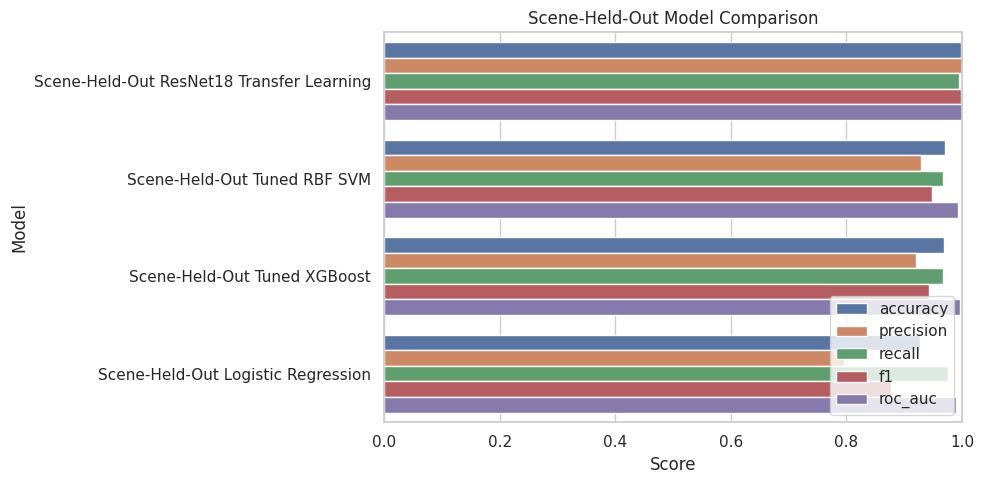

Saved figure: /content/drive/MyDrive/Project 2/outputs/scene_heldout_roc_overlay.png


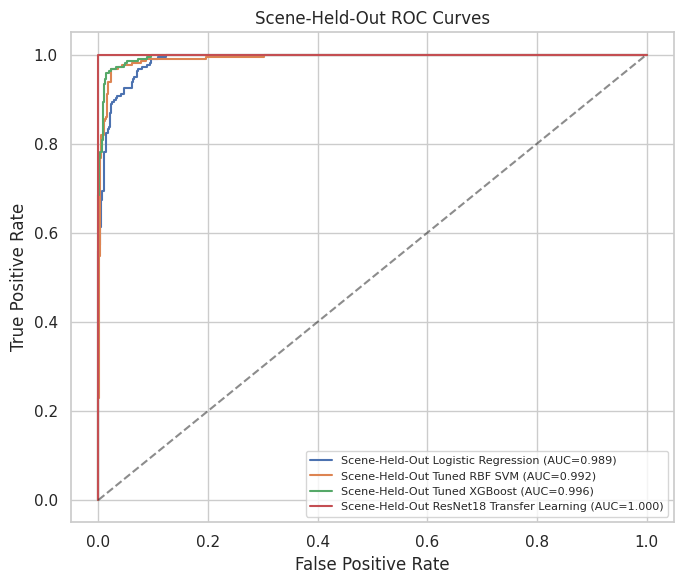

Saved table: /content/drive/MyDrive/Project 2/outputs/evaluation_protocol_comparison_long.csv


,model_family,f1_scene_heldout_split,f1_stratified_chip_split,roc_auc_scene_heldout_split,roc_auc_stratified_chip_split
0,CNN / ResNet18,0.9977,0.9825,1.0000,0.9990
1,Logistic Regression,0.8768,0.8782,0.9892,0.9823
2,Logistic Regression PCA,NaN,0.7226,NaN,0.9229
3,RBF SVM,0.9476,0.9360,0.9924,0.9891
4,Random Forest,NaN,0.9063,NaN,0.9872
5,XGBoost,0.9433,0.9333,0.9959,0.9893


Saved table: /content/drive/MyDrive/Project 2/outputs/evaluation_protocol_comparison.csv
Saved figure: /content/drive/MyDrive/Project 2/outputs/evaluation_protocol_f1_comparison.png


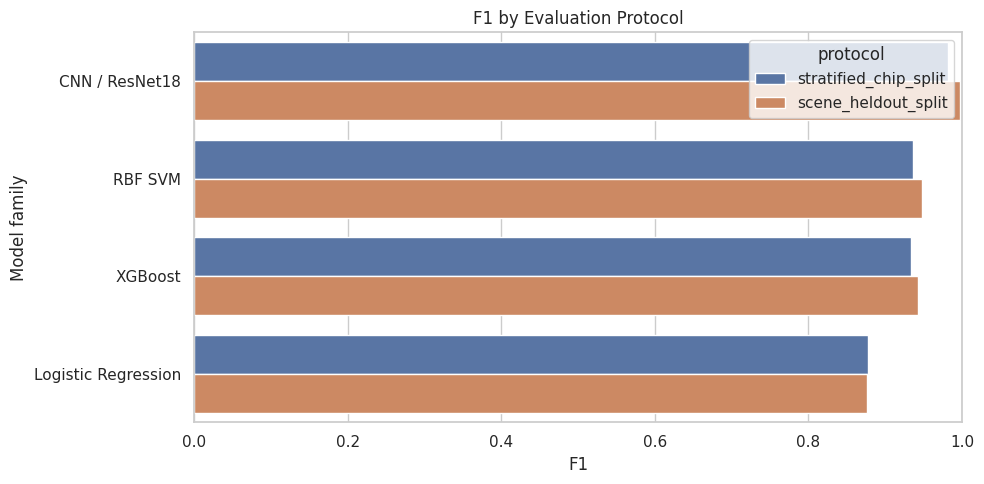

In [32]:
# Scene-held-out final comparison and protocol comparison
scene_heldout_model_metrics_df = scene_results_table(SCENE_HELDOUT_RESULTS)
track_artifact(save_table(scene_heldout_model_metrics_df, "scene_heldout_model_metrics.csv"), "Final scene-held-out model comparison", "Report scene-held-out results")

fig, ax = plt.subplots(figsize=(10, 5))
scene_plot_df = scene_heldout_model_metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=scene_plot_df, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Scene-Held-Out Model Comparison")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("Model")
ax.legend(loc="lower right")
track_artifact(save_fig("scene_heldout_model_metric_comparison.png", fig), "Scene-held-out model metric comparison", "Report and presentation generalization results")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for name, pred in SCENE_HELDOUT_PREDICTIONS.items():
    fpr, tpr, _ = roc_curve(y_group_test, pred["y_score"])
    auc = roc_auc_score(y_group_test, pred["y_score"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Scene-Held-Out ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)
track_artifact(save_fig("scene_heldout_roc_overlay.png", fig), "Scene-held-out ROC overlay", "Report and presentation generalization comparison")
plt.show()

# Compare the original stratified protocol with the stricter scene-held-out protocol.
def canonical_model_family(model_name):
    lowered = model_name.lower()
    if "resnet18" in lowered or "cnn" in lowered:
        return "CNN / ResNet18"
    if "xgboost" in lowered:
        return "XGBoost"
    if "svm" in lowered:
        return "RBF SVM"
    if "random forest" in lowered:
        return "Random Forest"
    if "pca" in lowered:
        return "Logistic Regression PCA"
    if "logistic regression" in lowered:
        return "Logistic Regression"
    return model_name

stratified_protocol_df = final_results_df.copy()
stratified_protocol_df["model_family"] = stratified_protocol_df["model"].map(canonical_model_family)
stratified_protocol_df["protocol"] = "stratified_chip_split"

scene_protocol_df = scene_heldout_model_metrics_df.copy()
scene_protocol_df["model_family"] = scene_protocol_df["model"].map(canonical_model_family)
scene_protocol_df["protocol"] = "scene_heldout_split"

protocol_long_df = pd.concat([stratified_protocol_df, scene_protocol_df], ignore_index=True)
protocol_long_df = protocol_long_df[["protocol", "model_family", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
track_artifact(save_table(protocol_long_df, "evaluation_protocol_comparison_long.csv", display_inline=False), "Long-form protocol comparison", "Report generalization comparison")

protocol_comparison_df = protocol_long_df.pivot_table(
    index="model_family",
    columns="protocol",
    values=["f1", "roc_auc"],
    aggfunc="max",
).reset_index()
protocol_comparison_df.columns = ["_".join([c for c in col if c]).strip("_") if isinstance(col, tuple) else col for col in protocol_comparison_df.columns]
track_artifact(save_table(protocol_comparison_df, "evaluation_protocol_comparison.csv"), "Stratified versus scene-held-out F1/ROC-AUC comparison", "Report generalization comparison")

fig, ax = plt.subplots(figsize=(10, 5))
protocol_f1_df = protocol_long_df[protocol_long_df["model_family"].isin(scene_protocol_df["model_family"].unique())]
sns.barplot(data=protocol_f1_df, x="f1", y="model_family", hue="protocol", ax=ax)
ax.set_title("F1 by Evaluation Protocol")
ax.set_xlim(0, 1)
ax.set_xlabel("F1")
ax.set_ylabel("Model family")
track_artifact(save_fig("evaluation_protocol_f1_comparison.png", fig), "F1 comparison across evaluation protocols", "Report and presentation generalization comparison")
plt.show()

## Draft Conclusions Template

Use the completed results above to fill in the final report. Recommended conclusion points:

1. State the best model by F1 and ROC-AUC, not just accuracy, because the dataset is imbalanced.
2. Compare hand-crafted feature models against the CNN and explain whether learned image features helped.
3. Discuss the class imbalance and why precision/recall/F1 matter for ship detection.
4. Explain the two evaluation protocols: the original stratified chip split answers the proposal's benchmark question, while the scene-held-out split tests generalization to new source scenes.
5. Interpret any difference between stratified and scene-held-out results. If scene-held-out performance drops, frame it as evidence that source-scene similarity made the original split optimistic. If it stays strong, frame it as stronger evidence that the model learned transferable ship cues.
6. Summarize what the unsupervised analysis showed about natural separation in the engineered feature space.
7. List limitations and future improvements, such as more robust scene-held-out cross-validation, stronger CNN fine-tuning, Grad-CAM-style interpretability, or full object detection on a dataset like ShipRSImageNet.

In [33]:
# Artifact index: files created for the report and presentation
artifact_df = pd.DataFrame(ARTIFACTS).drop_duplicates().reset_index(drop=True)
artifact_index_path = save_table(artifact_df, "artifact_index.csv", display_inline=True)

artifact_md = "# Artifact Index\n\n"
for _, row in artifact_df.iterrows():
    artifact_md += f"- `{Path(row['file']).name}`: {row['description']} ({row['suggested_use']})\n"
save_markdown(artifact_md, "artifact_index.md")

display(Markdown(artifact_md))

,file,description,suggested_use
0,/content/drive/MyDrive/Project 2/outputs/datas...,Dataset shape and class summary,Report data preparation section
1,/content/drive/MyDrive/Project 2/outputs/split...,"Train/test split diagnostics, including scene ...",Report data preparation and limitations
2,/content/drive/MyDrive/Project 2/outputs/class...,Class balance table,Report data section
3,/content/drive/MyDrive/Project 2/outputs/class...,Class balance bar chart,Report and presentation data overview
4,/content/drive/MyDrive/Project 2/outputs/sampl...,Representative image chips by class,Report data and presentation intro
...,...,...,...
60,/content/drive/MyDrive/Project 2/outputs/scene...,Scene-held-out model metric comparison,Report and presentation generalization results
61,/content/drive/MyDrive/Project 2/outputs/scene...,Scene-held-out ROC overlay,Report and presentation generalization comparison
62,/content/drive/MyDrive/Project 2/outputs/evalu...,Long-form protocol comparison,Report generalization comparison
63,/content/drive/MyDrive/Project 2/outputs/evalu...,Stratified versus scene-held-out F1/ROC-AUC co...,Report generalization comparison


Saved table: /content/drive/MyDrive/Project 2/outputs/artifact_index.csv
Saved markdown: /content/drive/MyDrive/Project 2/outputs/artifact_index.md


# Artifact Index

- `dataset_summary.csv`: Dataset shape and class summary (Report data preparation section)
- `split_diagnostics.csv`: Train/test split diagnostics, including scene overlap (Report data preparation and limitations)
- `class_balance.csv`: Class balance table (Report data section)
- `class_balance.png`: Class balance bar chart (Report and presentation data overview)
- `sample_images_by_class.png`: Representative image chips by class (Report data and presentation intro)
- `pixel_distributions.png`: Pixel intensity distributions by class (Report EDA section)
- `top_scene_metadata_summary.csv`: Top scenes by image count (Report leakage/metadata discussion)
- `scene_location_summary.png`: Scene counts and chip locations (Report EDA and limitations)
- `modeling_pipeline.png`: Project modeling pipeline diagram (Report and presentation overview)
- `handcrafted_features.csv`: Hand-crafted feature table (Methods appendix and reproducibility)
- `feature_summary.csv`: Feature summary statistics (Report feature engineering section)
- `logistic_regression_baseline_confusion_matrix.png`: Logistic Regression Baseline confusion matrix (Model comparison/report results)
- `logistic_regression_baseline_roc_curve.png`: Logistic Regression Baseline ROC curve (Model comparison/report results)
- `untuned_random_forest_baseline_confusion_matrix.png`: Untuned Random Forest Baseline confusion matrix (Model comparison/report results)
- `untuned_random_forest_baseline_roc_curve.png`: Untuned Random Forest Baseline ROC curve (Model comparison/report results)
- `baseline_model_metrics.csv`: Untuned benchmark metrics (Benchmarking section)
- `tuned_random_forest_confusion_matrix.png`: Tuned Random Forest confusion matrix (Model comparison/report results)
- `tuned_random_forest_roc_curve.png`: Tuned Random Forest ROC curve (Model comparison/report results)
- `tuned_rbf_svm_confusion_matrix.png`: Tuned RBF SVM confusion matrix (Model comparison/report results)
- `tuned_rbf_svm_roc_curve.png`: Tuned RBF SVM ROC curve (Model comparison/report results)
- `tuned_xgboost_confusion_matrix.png`: Tuned XGBoost confusion matrix (Model comparison/report results)
- `tuned_xgboost_roc_curve.png`: Tuned XGBoost ROC curve (Model comparison/report results)
- `tuned_cv_summary.csv`: Cross-validation summary and best hyperparameters (Training and tuning section)
- `tuned_model_metrics.csv`: Tuned traditional model metrics (Training and tuning section)
- `traditional_model_comparison.csv`: Combined traditional model comparison (Final model comparison)
- `traditional_model_metric_comparison.png`: Traditional model metric comparison (Report and presentation model results)
- `pca_explained_variance.csv`: PCA explained variance table (Unsupervised analysis section)
- `pca_explained_variance.png`: PCA cumulative explained variance (Report unsupervised analysis)
- `pca_2d_by_label.png`: 2D PCA projection colored by label (Report unsupervised analysis)
- `kmeans_cluster_crosstab.csv`: K-Means cluster by class crosstab (Unsupervised analysis section)
- `kmeans_cluster_metrics.csv`: K-Means label agreement metrics (Unsupervised analysis section)
- `kmeans_on_pca_projection.png`: K-Means clusters on PCA projection (Report unsupervised analysis)
- `tsne_feature_projection.png`: t-SNE feature projection (Report unsupervised analysis and presentation)
- `logistic_regression_pca_10_confusion_matrix.png`: Logistic Regression PCA-10 confusion matrix (Model comparison/report results)
- `logistic_regression_pca_10_roc_curve.png`: Logistic Regression PCA-10 ROC curve (Model comparison/report results)
- `pca_reduced_model_metrics.csv`: PCA-reduced feature model metrics (Optional extension/results comparison)
- `cnn_training_history.csv`: CNN training history (CNN results and learning curve discussion)
- `cnn_training_curves.png`: CNN training and validation curves (Report CNN section and presentation)
- `cnn_test_metrics.csv`: CNN held-out test metrics (CNN results section)
- `cnn_confusion_matrix.png`: CNN confusion matrix (CNN results section)
- `cnn_roc_curve.png`: CNN ROC curve (CNN results section and presentation)
- `cnn_prediction_examples.png`: CNN correct/incorrect prediction examples (Presentation model behavior slide)
- `final_supervised_model_comparison.csv`: Final supervised model comparison (Report conclusions and presentation results)
- `final_model_metric_comparison.png`: Final supervised model comparison chart (Presentation final results slide)
- `final_roc_overlay.png`: Final ROC overlay (Report and presentation final comparison)
- `scene_heldout_split_summary.csv`: Scene-held-out train/test split summary (Report generalization and limitations section)
- `scene-held-out_logistic_regression_confusion_matrix.png`: Scene-Held-Out Logistic Regression scene-held-out confusion matrix (Scene-held-out model comparison)
- `scene-held-out_logistic_regression_roc_curve.png`: Scene-Held-Out Logistic Regression scene-held-out ROC curve (Scene-held-out model comparison)
- `scene-held-out_tuned_rbf_svm_confusion_matrix.png`: Scene-Held-Out Tuned RBF SVM scene-held-out confusion matrix (Scene-held-out model comparison)
- `scene-held-out_tuned_rbf_svm_roc_curve.png`: Scene-Held-Out Tuned RBF SVM scene-held-out ROC curve (Scene-held-out model comparison)
- `scene-held-out_tuned_xgboost_confusion_matrix.png`: Scene-Held-Out Tuned XGBoost scene-held-out confusion matrix (Scene-held-out model comparison)
- `scene-held-out_tuned_xgboost_roc_curve.png`: Scene-Held-Out Tuned XGBoost scene-held-out ROC curve (Scene-held-out model comparison)
- `scene_heldout_traditional_cv_summary.csv`: Scene-held-out traditional model CV summary (Scene-held-out tuning section)
- `scene_heldout_traditional_metrics.csv`: Scene-held-out traditional model metrics (Scene-held-out model comparison)
- `scene_heldout_cnn_training_history.csv`: Scene-held-out CNN training history (Scene-held-out CNN learning curve discussion)
- `scene_heldout_cnn_training_curves.png`: Scene-held-out CNN training and validation curves (Scene-held-out CNN section and presentation)
- `scene_heldout_cnn_test_metrics.csv`: Scene-held-out CNN held-out test metrics (Scene-held-out CNN results)
- `scene_heldout_cnn_confusion_matrix.png`: Scene-held-out CNN confusion matrix (Scene-held-out CNN results)
- `scene_heldout_cnn_roc_curve.png`: Scene-held-out CNN ROC curve (Scene-held-out CNN results and presentation)
- `scene_heldout_model_metrics.csv`: Final scene-held-out model comparison (Report scene-held-out results)
- `scene_heldout_model_metric_comparison.png`: Scene-held-out model metric comparison (Report and presentation generalization results)
- `scene_heldout_roc_overlay.png`: Scene-held-out ROC overlay (Report and presentation generalization comparison)
- `evaluation_protocol_comparison_long.csv`: Long-form protocol comparison (Report generalization comparison)
- `evaluation_protocol_comparison.csv`: Stratified versus scene-held-out F1/ROC-AUC comparison (Report generalization comparison)
- `evaluation_protocol_f1_comparison.png`: F1 comparison across evaluation protocols (Report and presentation generalization comparison)


## Package Report and Presentation Artifacts

Run this cell after the artifact index has been generated. It creates a zip archive of the full `outputs/` folder and saves it next to the `shipsnet.json` file that was loaded. If the data came from Google Drive, the zip will appear in that same Drive folder for manual download.

In [36]:
# Zip all generated artifacts next to the loaded shipsnet.json file
import shutil

archive_dir = DATA_PATH.parent
archive_base = archive_dir / "ship_detection_outputs"
archive_path = archive_base.with_suffix(".zip")

if archive_path.exists():
    archive_path.unlink()

shutil.make_archive(str(archive_base), "zip", root_dir=OUTPUT_DIR)
archive_size_mb = archive_path.stat().st_size / (1024 * 1024)
print(f"Created artifact archive: {archive_path}")
print(f"Archive size: {archive_size_mb:.2f} MB")

if IN_COLAB and str(archive_path).startswith("/content/drive/"):
    print("Download this file manually from the same Google Drive folder as shipsnet.json after Drive finishes syncing.")
elif IN_COLAB:
    print("The data was loaded from the Colab runtime, so this archive is not in Drive. Use the file browser or files.download if needed.")
else:
    print("Archive created next to the local shipsnet.json file.")

Created artifact archive: /content/drive/MyDrive/Project 2/ship_detection_outputs.zip
Archive size: 5.81 MB
Download this file manually from Google Drive after the notebook finishes syncing.


## Presentation Talking Points

**Slide 1: Problem and motivation**  
Detect ships in 80x80 satellite image chips using binary classification.

**Slide 2: Dataset and preprocessing**  
4,000 image chips, 1,000 ship and 3,000 no-ship, reshaped to RGB images and split into train/test sets. Mention that metadata includes source `scene_id` values.

**Slide 3: Feature engineering**  
Traditional models used RGB/HSV statistics, edge density, texture descriptors, entropy, and Hu moments.

**Slide 4: Benchmarks**  
Show the untuned Logistic Regression baseline and explain why it is the reference point.

**Slide 5: Tuned traditional models**  
Compare Random Forest, RBF SVM, and gradient boosting. Use the saved metric comparison and ROC curves.

**Slide 6: Unsupervised findings**  
Use PCA/t-SNE/K-Means visuals to explain how much natural class separation appears in the engineered feature space.

**Slide 7: CNN comparison**  
Show CNN learning curves, confusion matrix, ROC curve, and prediction examples. Explain whether direct pixel learning improved over engineered features.

**Slide 8: Scene-held-out generalization check**  
Explain that the proposal-aligned stratified split had overlapping source scenes, then show the no-overlap scene-held-out comparison. Emphasize that augmentation helps robustness, but grouped evaluation is what tests generalization to new scenes.

**Slide 9: Final conclusion**  
State the best model, key metrics under both evaluation protocols, tradeoffs, limitations, and next steps such as stronger CNN tuning, scene-held-out cross-validation, Grad-CAM interpretability, or object detection on ShipRSImageNet.